# Ejercicio 1.


### Juan Pablo Guzmán Segura			A01039810
### Valeria Mariane Cárdenas Rodríguez 	      A01721814
### Rodrigo Leal Torres			      A00836930
### Ana Karen Márquez Escobar		      A01028413
### Pablo Pérez Sandoval			      A01710355

In [ ]:
#Importar las librerias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#Cargar los datos en la variable df
df = pd.read_csv('reto_inegi_dataset.csv').astype(str)
df.head(-5)

<ipython-input-108-ff6c214e35e6>:2: DtypeWarning: Columns (83,84,167) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('reto_inegi_dataset.csv').astype(str)


,Unnamed: 0,folioviv,foliohog,numren,parentesco,sexo,edad,madre_hog,madre_id,padre_hog,...,num_trabaj,c_futuro,ct_futuro,entidad,est_dis,upm,factor,ing_tri_total,ing_tri_max,clave_max
0,0,100005002,1,1,101,2,91,2,,2,...,,,,1,3,1,206,7434.78,7434.78,P104
1,1,100005002,1,2,301,2,48,1,01,2,...,1,,,1,3,1,206,35706.509999999995,33749.99,P001
2,2,100005002,1,3,609,2,13,1,02,2,...,,,,1,3,1,206,1369.56,978.26,P041
3,3,100005003,1,1,101,1,68,2,,2,...,1,,,1,3,1,206,78016.28,52826.08,P001
4,4,100005003,1,2,201,2,64,2,,2,...,1,,,1,3,1,206,21032.6,11739.13,P024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309674,309674,3260797908,1,3,301,2,10,1,&,1,...,,,,32,560,10232,123,nan,nan,nan
309675,309675,3260797909,1,1,101,1,37,2,,2,...,1,,,32,560,10232,123,26413.04,26413.04,P001
309676,309676,3260797909,1,2,201,2,31,2,,2,...,,,,32,560,10232,123,nan,nan,nan
309677,309677,3260797909,1,3,301,2,6,1,02,1,...,,,,32,560,10232,123,nan,nan,nan


### Vistazo inicial a los datos
Revisar el dataset, estadísticas importantes y cantidad de datos vacios.

In [ ]:
df.shape

(309684, 192)

In [ ]:
#Observar como estan compuestas las columnas
df.dtypes

Unnamed: 0       object
folioviv         object
foliohog         object
numren           object
parentesco       object
                  ...  
upm              object
factor           object
ing_tri_total    object
ing_tri_max      object
clave_max        object
Length: 192, dtype: object

Cambiar las columnas que vamos a utilizar como valores númericos a tipo int o float.

In [ ]:
df['numren'] = df['numren'].astype(int)
df['edad'] = df['edad'].astype(int)
df['ing_tri_total'] = df['ing_tri_total'].astype(float)
df['ing_tri_max'] = df['ing_tri_max'].astype(float)
df.describe()

,numren,edad,ing_tri_total,ing_tri_max
count,309684.000000,309684.000000,2.051440e+05,2.051440e+05
mean,2.678653,33.273130,2.368618e+04,2.018603e+04
std,1.667742,21.691438,5.086255e+04,4.719916e+04
min,1.000000,0.000000,9.700000e-01,9.700000e-01
25%,1.000000,15.000000,5.680320e+03,5.282600e+03
50%,2.000000,30.000000,1.614130e+04,1.408695e+04
75%,4.000000,50.000000,2.910325e+04,2.465217e+04
max,19.000000,109.000000,6.854754e+06,6.854754e+06


In [ ]:
J = df['ing_tri_total'].max()
J

6854754.09

#### Visualización de datos iniciales
Gráficar ciertas columnas claves para observar tendencias o relaciones entre las variables.

En este nuevo dataset solo utilizaremos los valores en donde trabajo_mp sean iguales a 1, ya que esto nos indica que la persona trabajo el mes pasado.

In [ ]:
# Crear un nuevo dataset en el que realizaremos
# modificaciones para no afectar el Df original
df2 = df[df['trabajo_mp']== '1']
df2 = df[df['edad']>= 18]
df2.describe()

,numren,edad,ing_tri_total,ing_tri_max
count,217375.000000,217375.000000,1.805830e+05,1.805830e+05
mean,2.009532,43.549852,2.637773e+04,2.244066e+04
std,1.202133,17.477430,5.361057e+04,4.984683e+04
min,1.000000,18.000000,1.460000e+00,1.460000e+00
25%,1.000000,29.000000,8.510860e+03,6.639340e+03
50%,2.000000,42.000000,1.844021e+04,1.593442e+04
75%,2.000000,56.000000,3.127866e+04,2.655737e+04
max,19.000000,109.000000,6.854754e+06,6.854754e+06


Para saber si el ingreso de una persona es mayor o menor a 25k trimestrales crearemos una función en donde el resultado será guardado en la columna Umbral.

In [ ]:
def mayor_menor(valor):
    if valor >= 25000:
        return '>=25k'
    else:
        return '<25k'
#Umbral
df2['umbral']  = df['ing_tri_total'].apply(mayor_menor)
df2['umbral'].head()

<ipython-input-114-1260a55a5d26>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['umbral']  = df['ing_tri_total'].apply(mayor_menor)


0     <25k
1    >=25k
3    >=25k
4     <25k
5    >=25k
Name: umbral, dtype: object

sexo: 1, Cantidad: 102298
sexo: 2, Cantidad: 115077


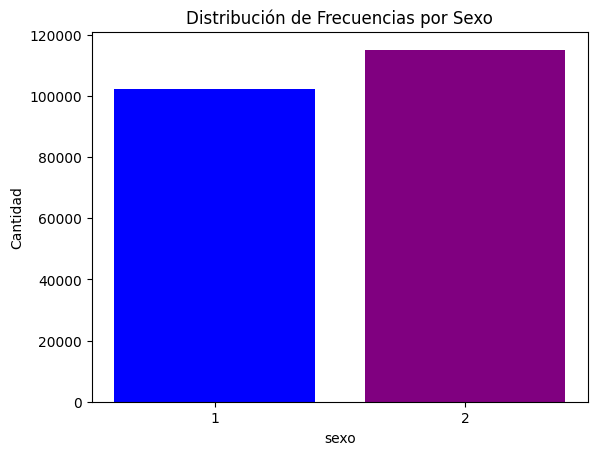

In [ ]:
#Gráfica con los valores de hombres y mujeres encuestados

valores, conteos = np.unique(df2['sexo'], return_counts=True)

for edad, conteo in zip(valores, conteos):
    print(f"sexo: {edad}, Cantidad: {conteo}")

plt.bar(valores, conteos, color=['blue','purple'])
plt.xlabel('sexo')
plt.ylabel('Cantidad')
plt.title('Distribución de Frecuencias por Sexo')
plt.show()

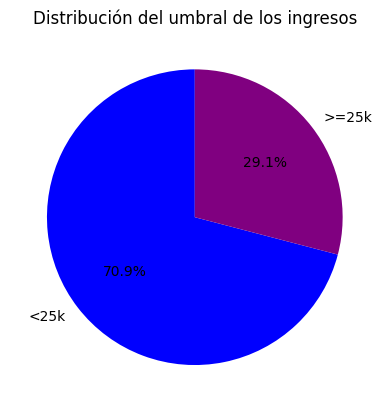

In [ ]:
# Visualizar personas con ingresos mayores a 25k

labels, counts = np.unique(df2['umbral'], return_counts=True)
labels, counts
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['blue', 'purple'])
plt.title('Distribución del umbral de los ingresos')
plt.show()

<Axes: title={'center': 'Frecuencia de Sexo por Ingreso de 25k'}, xlabel='sexo'>

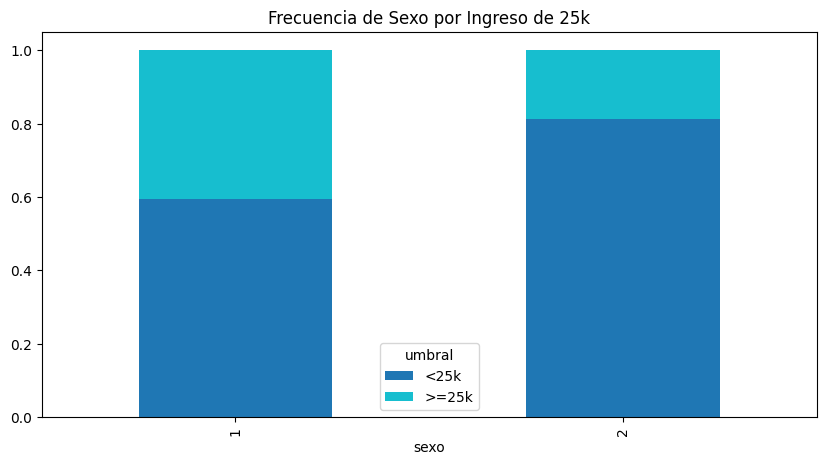

In [ ]:
#Se agrega una condición a la gráfica de SEXO en donde se colorea la gráfica dependidendo de si se ganan más o menos de 25k
df_sub = pd.crosstab(index=df2['sexo'],
                    columns=df2['umbral'],
                    normalize="index")
df_sub.plot(kind='bar',
                stacked=True,
                colormap='tab10', figsize=(10,5),
                title='Frecuencia de Sexo por Ingreso de 25k')

<ipython-input-118-96a1fabe8adb>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['entidad'] = df2['entidad'].astype(int)


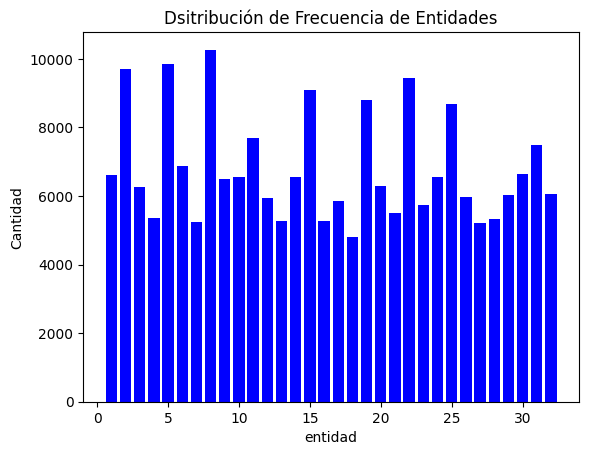

In [ ]:
#Sacar los valores únicos para la columna entidad
df2['entidad'] = df2['entidad'].astype(int)
valores, conteos = np.unique(df2['entidad'], return_counts=True)
# #Iterar los valores únicos y sacar un conteo
# for entidad, conteo in zip(valores, conteos):
#     print(f"entidad: {entidad}, Cantidad: {conteo}")


# Graficar la distribución de las entidades
plt.bar(valores, conteos, color='blue')
plt.xlabel('entidad')
plt.ylabel('Cantidad')
plt.title('Dsitribución de Frecuencia de Entidades')
plt.show()

<Axes: title={'center': 'Frecuencia de Entidades por Ingreso de 25k (normalizado)'}, xlabel='entidad'>

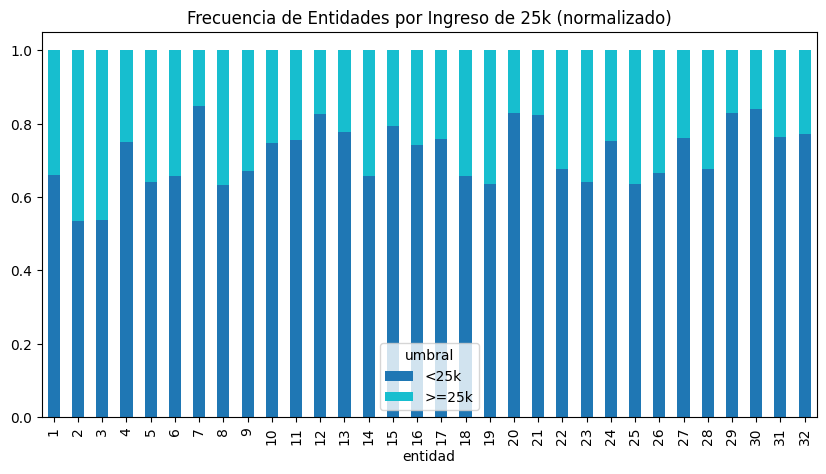

In [ ]:
#Graficar la cantidad de personas que ganan más o menos de 25k según su entidad

df_sub = pd.crosstab(index=df2['entidad'],
                    columns=df2['umbral'],
                    normalize="index")
df_sub.plot(kind='bar',
                stacked=True,
                colormap='tab10', figsize=(10,5),
                title='Frecuencia de Entidades por Ingreso de 25k (normalizado)')

Edad: 18, Cantidad: 5544
Edad: 19, Cantidad: 4888
Edad: 20, Cantidad: 5157
Edad: 21, Cantidad: 4901
Edad: 22, Cantidad: 5578
Edad: 23, Cantidad: 4793
Edad: 24, Cantidad: 4591
Edad: 25, Cantidad: 4610
Edad: 26, Cantidad: 4356
Edad: 27, Cantidad: 4429
Edad: 28, Cantidad: 4633
Edad: 29, Cantidad: 4032
Edad: 30, Cantidad: 5042
Edad: 31, Cantidad: 3812
Edad: 32, Cantidad: 4609
Edad: 33, Cantidad: 4132
Edad: 34, Cantidad: 3954
Edad: 35, Cantidad: 4223
Edad: 36, Cantidad: 4132
Edad: 37, Cantidad: 3882
Edad: 38, Cantidad: 4471
Edad: 39, Cantidad: 3857
Edad: 40, Cantidad: 4768
Edad: 41, Cantidad: 3242
Edad: 42, Cantidad: 4788
Edad: 43, Cantidad: 3870
Edad: 44, Cantidad: 3517
Edad: 45, Cantidad: 4159
Edad: 46, Cantidad: 3687
Edad: 47, Cantidad: 3859
Edad: 48, Cantidad: 4068
Edad: 49, Cantidad: 3857
Edad: 50, Cantidad: 4701
Edad: 51, Cantidad: 3167
Edad: 52, Cantidad: 4083
Edad: 53, Cantidad: 3441
Edad: 54, Cantidad: 3492
Edad: 55, Cantidad: 3281
Edad: 56, Cantidad: 3310
Edad: 57, Cantidad: 3074


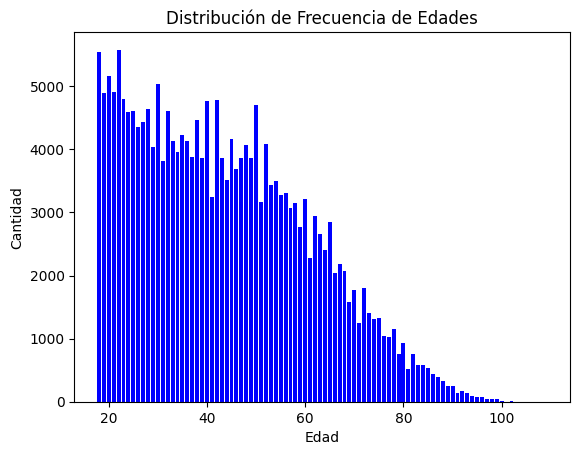

In [ ]:
#Sacar los valores únicos para la columna edad
valores, conteos = np.unique(df2['edad'], return_counts=True)

#Iterar los valores únicos y sacar un conteo
for edad, conteo in zip(valores, conteos):
     print(f"Edad: {edad}, Cantidad: {conteo}")

#Graficar la distribución de las edades
plt.bar(valores, conteos, color='blue')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.title('Distribución de Frecuencia de Edades')
plt.show()

<ipython-input-121-c5d072a9cbd6>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['edad'] = pd.to_numeric(df2['edad'], errors='coerce')
<ipython-input-121-c5d072a9cbd6>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.dropna(subset=['edad'], inplace=True)


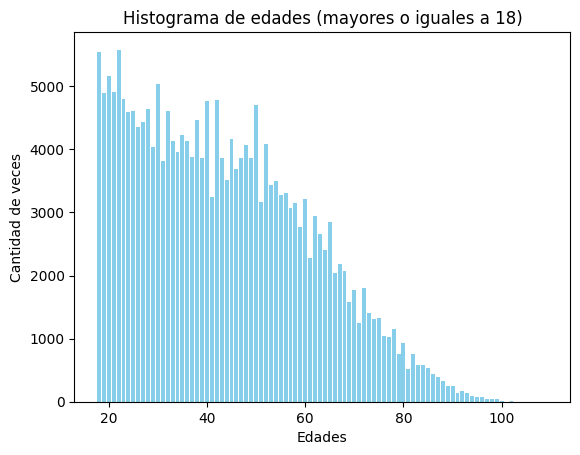

In [ ]:
# Asegurarse de que la columna 'edad' sea de tipo numérico
df2['edad'] = pd.to_numeric(df2['edad'], errors='coerce')
df2.dropna(subset=['edad'], inplace=True)

# Filtrado de la edad
limite_edad = 18
edades_filtradas = df2[df2['edad'] >= limite_edad]

# Obtener la frecuencia de las edades
valores_unicos, conteos = np.unique(edades_filtradas['edad'], return_counts=True)
valores_unicos, conteos

#Graficar resultados
plt.bar(valores_unicos, conteos, color='skyblue')
plt.xlabel('Edades')
plt.ylabel('Cantidad de veces')
plt.title('Histograma de edades (mayores o iguales a {})'.format(limite_edad))
plt.show()

<ipython-input-122-f78819ee4222>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['rango_edad'] = pd.cut(df2['edad'], bins=bins, labels=labels, right=False)


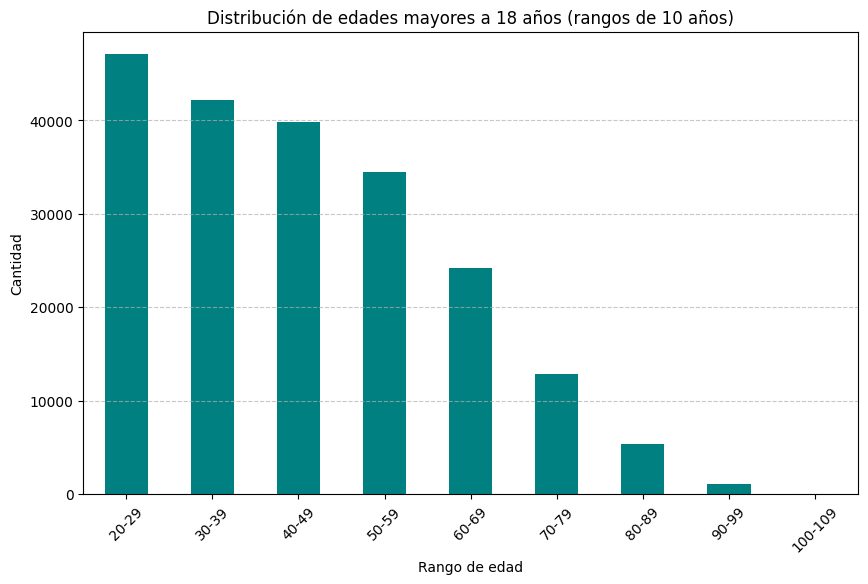

In [ ]:


# Crear intervalos de 10 años desde 20 hasta el máximo + 10
bins = np.arange(20, df2['edad'].max() + 10, 10)  # Asegúrate de cubrir el valor máximo
labels = [f'{i}-{i+9}' for i in bins[:-1]]  # Crear etiquetas para los rangos

# Agrupar las edades en esos intervalos
df2['rango_edad'] = pd.cut(df2['edad'], bins=bins, labels=labels, right=False)

# Contar frecuencias en cada rango de edad
conteo_rango_edad = df2['rango_edad'].value_counts().sort_index()

# Graficar los resultados
plt.figure(figsize=(10, 6))
conteo_rango_edad.plot(kind='bar', color='teal')
plt.xlabel('Rango de edad')
plt.ylabel('Cantidad')
plt.title('Distribución de edades mayores a 18 años (rangos de 10 años)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<Axes: title={'center': 'Frecuencia de Rango de Edad por Ingreso de 25k (normalizado)'}, xlabel='rango_edad'>

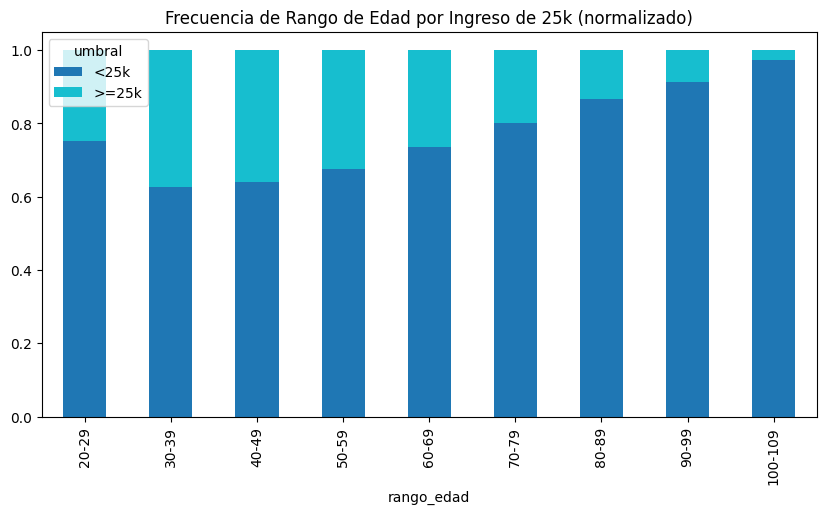

In [ ]:
#Graficar el ingreso de las personas según el rango de edad
df_sub = pd.crosstab(index=df2['rango_edad'],
                    columns=df2['umbral'],
                    normalize="index")
df_sub.plot(kind='bar',
                stacked=True,
                colormap='tab10', figsize=(10,5),
                title='Frecuencia de Rango de Edad por Ingreso de 25k (normalizado)')

KeyboardInterrupt: 

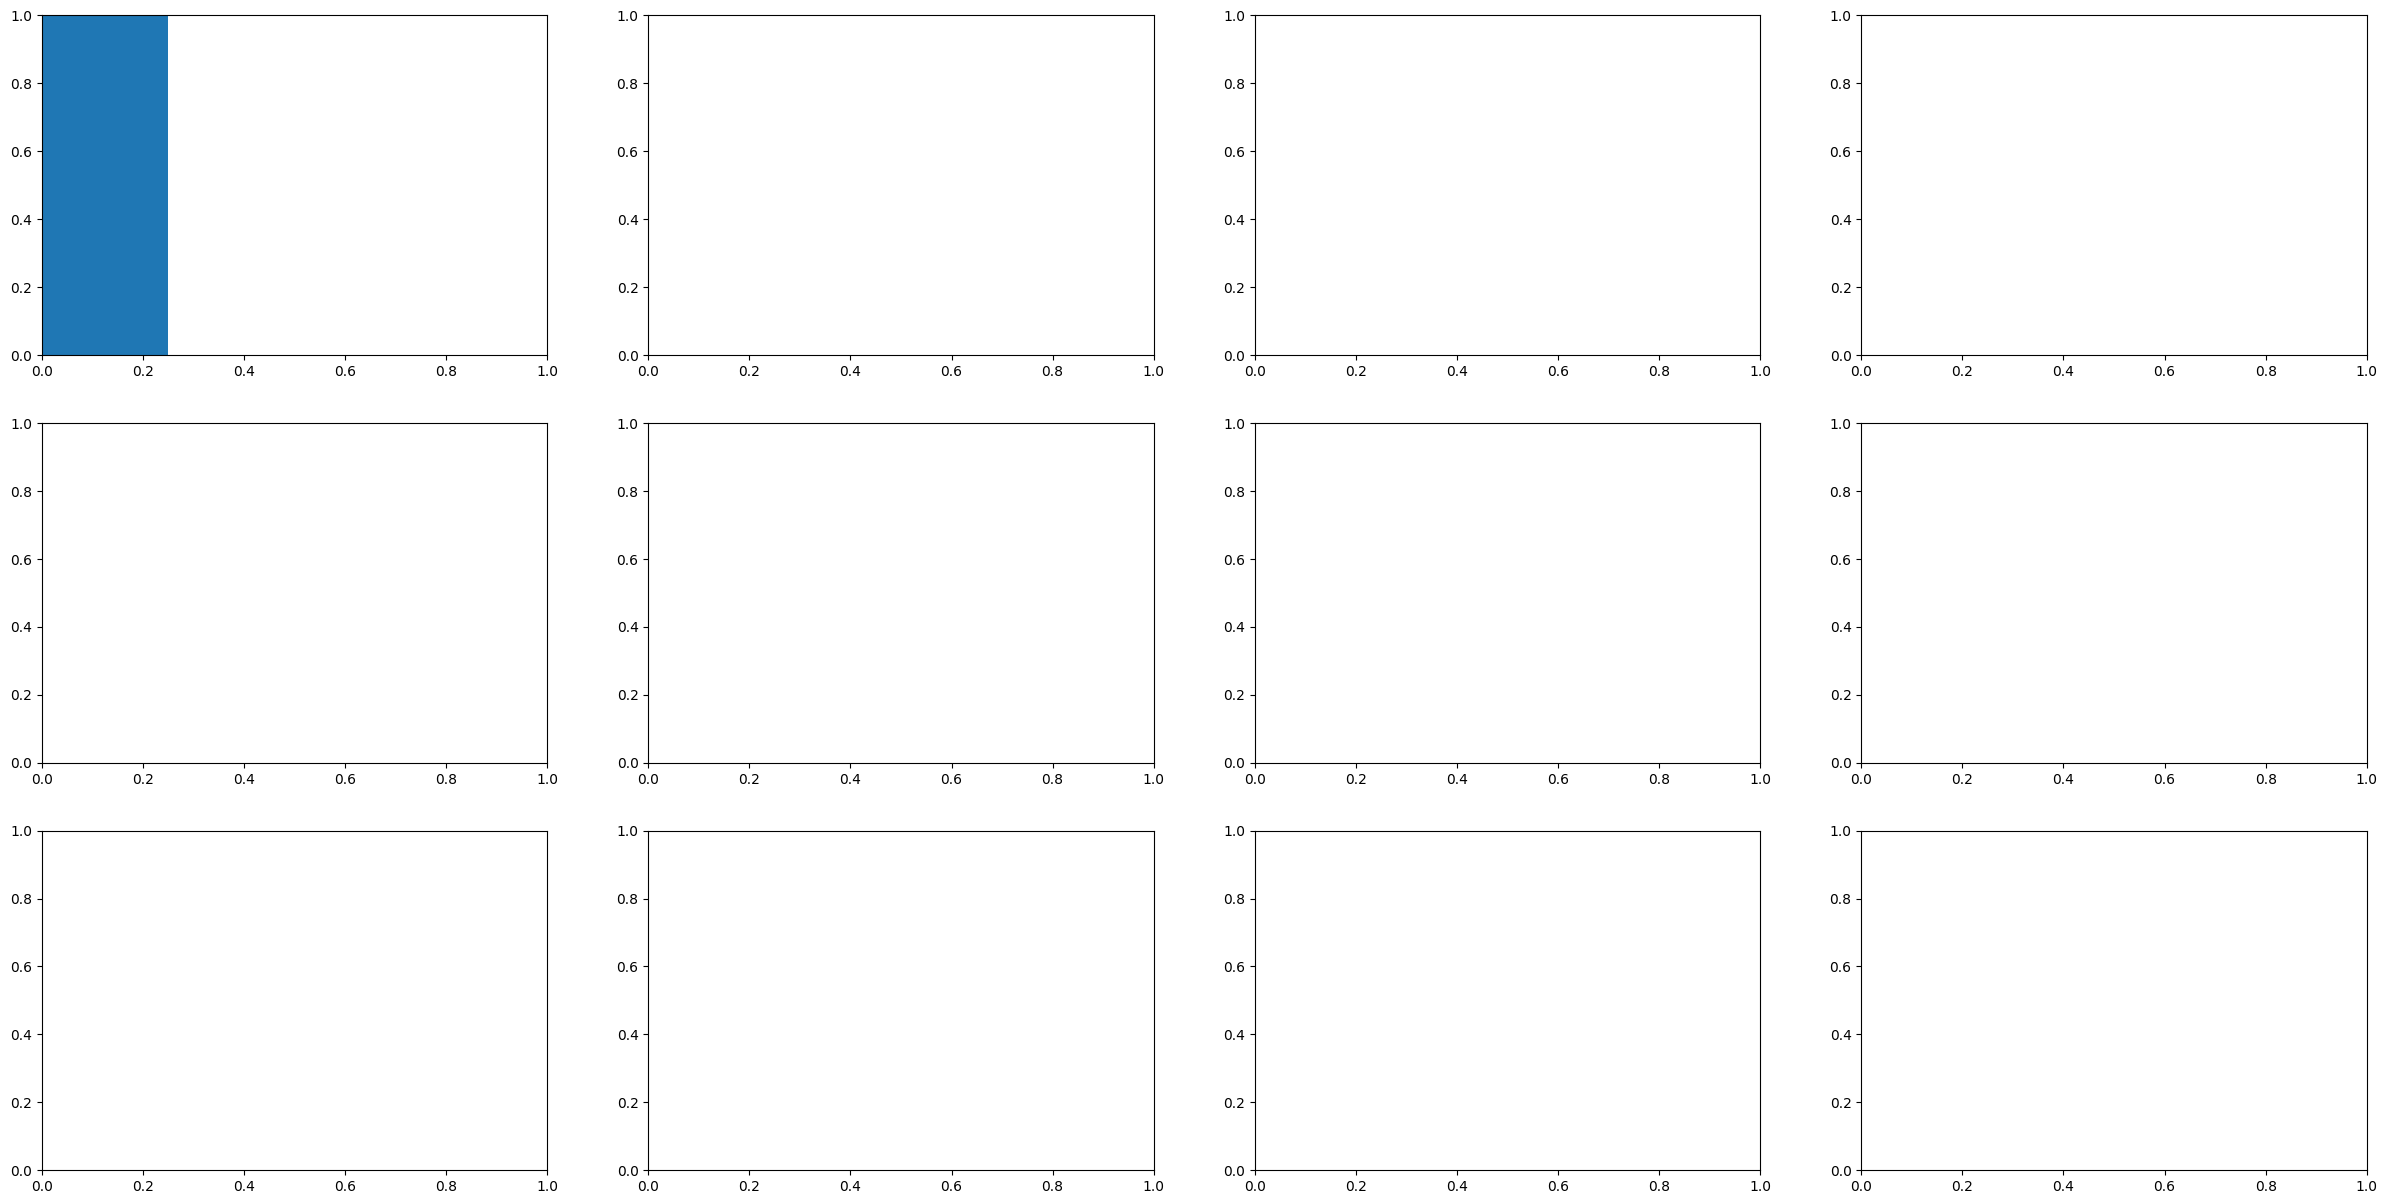

In [ ]:
import matplotlib.pyplot as plt

# Asumiendo que df2 es tu dataframe y ya está cargado con las columnas necesarias.

# Definir número máximo de filas y columnas para subplots
max_rows, max_cols = 3, 4
fig, axes = plt.subplots(max_rows, max_cols, figsize=(30, 15))

# Seleccionar solo las columnas necesarias para mejorar la eficiencia
object_cols = df2.select_dtypes(include='object').columns

# Crear subplots dinámicamente basado en la cantidad necesaria de gráficos
for i, feature in enumerate(object_cols):
    row, col = divmod(i, max_cols)
    if row >= max_rows:  # Evita crear más gráficos de los que el grid permite
        break

    # Crear la tabla cruzada
    df_sub = pd.crosstab(index=df2[feature], columns=df2['umbral'])

    # Plotear los datos
    df_sub.plot(kind='bar', stacked=True, colormap='tab10', ax=axes[row][col])

fig.tight_layout()
plt.show()


In [ ]:
# Crear intervalos de 10 años
bins = np.arange(20, df2['edad'].max() + 10, 10)
df2['rango_edad'] = pd.cut(df2['edad'], bins=bins, labels=[f'{i}-{i+9}' for i in bins[:-1]], right=False)

# Asignar categorías de ingreso basadas en algún umbral
def categorizar_ingresos(ingreso):
    return '>25k' if ingreso > 25000 else '<=25k'

df2['income'] = df2['ing_tri_total'].apply(categorizar_ingresos)

# Configuración inicial de la figura
fig, axes = plt.subplots(3, 4, figsize=(30, 15))  # Ajusta el número de filas/columnas según las características
row, column = 0, 0

# Seleccionar características categóricas y la nueva 'rango_edad'
features_to_plot = ['rango_edad'] + df2.select_dtypes(include='object').columns.tolist()

# Crear gráficos para cada característica categórica
for feature in features_to_plot:
    if feature in df2.columns:
        df_sub = pd.crosstab(index=df2[feature], columns=df2['income'])
        df_sub.plot(kind='bar', stacked=True, colormap='tab10', ax=axes[row][column], title=feature)
        column += 1
        if column == 4:  # Restablece column para la siguiente fila
            column = 0
            row += 1
        if row == 3:  # Salir del loop si no hay más espacio en la subfigura (ajusta según tu necesidad)
            break

# Ajustar la disposición y mostrar el gráfico
fig.tight_layout()
plt.show()


In [ ]:
#Graficar las columnas numren, edad y los ingresos dependiendo de la cantidad del ingreso
import seaborn as sns

fig, axes = plt.subplots(2,3, figsize=(16,15))
row = 0
column = 0

for i, feature in enumerate(df2.select_dtypes(include=['int', 'float'])):
    sns.histplot(x=feature, data=df2,ax= axes[row][column], hue=df2['umbral'])
    if column == 2:
        column = 0
        row = 1
    else:
        column +=1
fig.tight_layout()
plt.show()

<Axes: title={'center': 'Frecuencia de Nivel de Estudio por Ingreso de 25k'}, xlabel='nivelaprob'>

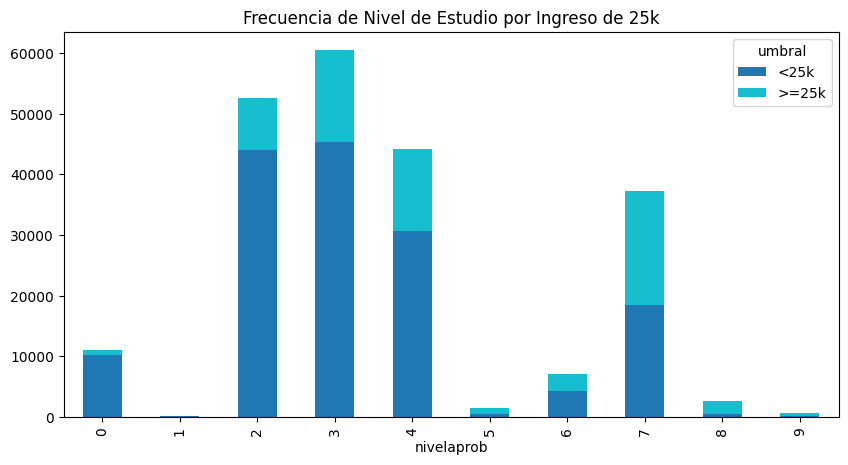

In [ ]:
# Graficar el ingreso de las personas según el rango de edad
df_sub = pd.crosstab(index=df2['nivelaprob'],
                    columns=df2['umbral'])
df_sub.plot(kind='bar',
                stacked=True,
                colormap='tab10', figsize=(10,5),
                title='Frecuencia de Nivel de Estudio por Ingreso de 25k')

<Axes: title={'center': 'Frecuencia de Nivel de Esudio por Ingreso de 25k (Normalizado)'}, xlabel='nivelaprob'>

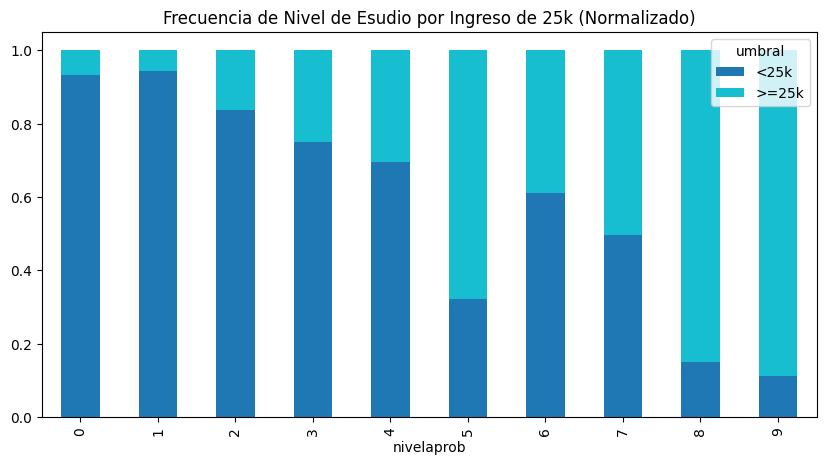

In [ ]:
#Graficar el ingreso de las personas según el rango de edad
df_sub = pd.crosstab(index=df2['nivelaprob'],
                    columns=df2['umbral'],
                    normalize="index")
df_sub.plot(kind='bar',
                stacked=True,
                colormap='tab10', figsize=(10,5),
                title='Frecuencia de Nivel de Esudio por Ingreso de 25k (Normalizado)')

## Datos de discapacidad
¿Qué significa cada uno de los números de las capacidades?

1. No puede hacerlo
2. Lo hace con mucha dificultad
3. Lo hace con poca dificultad
4. No tiene dificultad

<Axes: title={'center': 'Frecuencia de Personas con Discapacidad para Caminar por Ingreso de 25k'}, xlabel='disc_camin'>

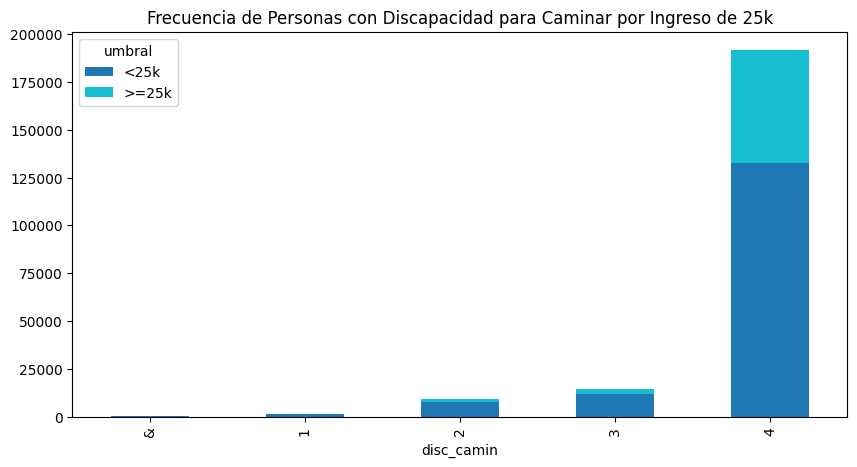

In [ ]:
# Graficar el ingreso de las personas según la discapacidad de caminar
df_sub = pd.crosstab(index=df2['disc_camin'],
                    columns=df2['umbral'])
df_sub.plot(kind='bar',
                stacked=True,
                colormap='tab10', figsize=(10,5),
                title='Frecuencia de Personas con Discapacidad para Caminar por Ingreso de 25k')

<Axes: title={'center': 'Frecuencia de Personas con Discapacidad para Ver por Ingreso de 25k'}, xlabel='disc_ver'>

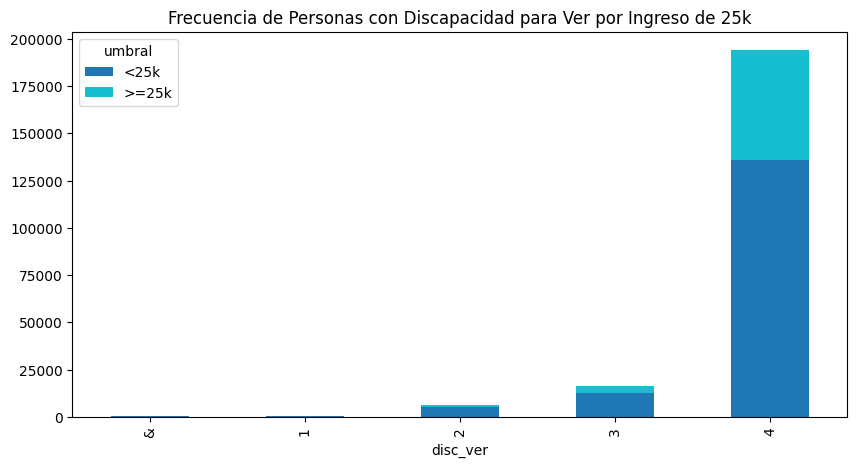

In [ ]:
# Graficar el ingreso de las personas según la discapacidad de ver
df_sub = pd.crosstab(index=df2['disc_ver'],
                    columns=df2['umbral'])
df_sub.plot(kind='bar',
                stacked=True,
                colormap='tab10', figsize=(10,5),
                title='Frecuencia de Personas con Discapacidad para Ver por Ingreso de 25k')

<Axes: title={'center': 'Frecuencia de Personas con Discapacidad para Usar Brazos por Ingreso de 25k'}, xlabel='disc_brazo'>

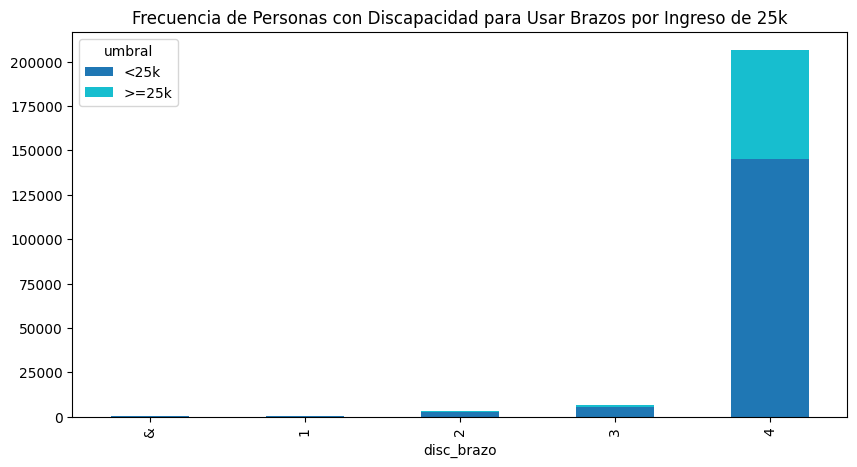

In [ ]:
# Graficar el ingreso de las personas según la discapacidad de usar brazos
df_sub = pd.crosstab(index=df2['disc_brazo'],
                    columns=df2['umbral'])
df_sub.plot(kind='bar',
                stacked=True,
                colormap='tab10', figsize=(10,5),
                title='Frecuencia de Personas con Discapacidad para Usar Brazos por Ingreso de 25k')

<Axes: title={'center': 'Frecuencia de Personas con Discapacidad para Aprender por Ingreso de 25k'}, xlabel='disc_apren'>

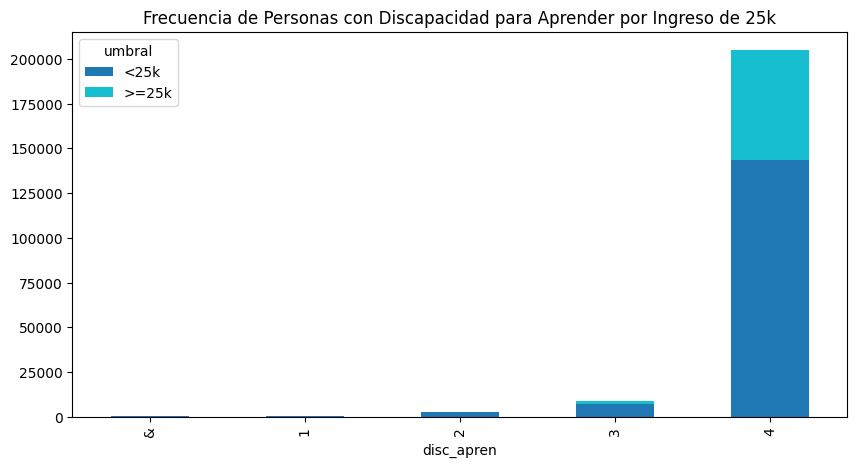

In [ ]:
# Graficar el ingreso de las personas según la discapacidad para aprender
df_sub = pd.crosstab(index=df2['disc_apren'],
                    columns=df2['umbral'])
df_sub.plot(kind='bar',
                stacked=True,
                colormap='tab10', figsize=(10,5),
                title='Frecuencia de Personas con Discapacidad para Aprender por Ingreso de 25k')

<Axes: title={'center': 'Frecuencia de Personas con Discapacidad Auditiva por Ingreso de 25k'}, xlabel='disc_oir'>

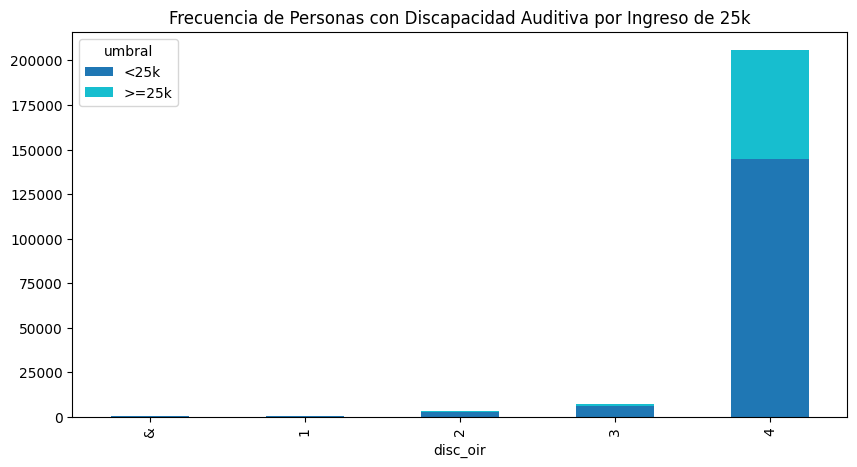

In [ ]:
# Graficar el ingreso de las personas según la discapacidad auditiva
df_sub = pd.crosstab(index=df2['disc_oir'],
                    columns=df2['umbral'])
df_sub.plot(kind='bar',
                stacked=True,
                colormap='tab10', figsize=(10,5),
                title='Frecuencia de Personas con Discapacidad Auditiva por Ingreso de 25k')

<Axes: title={'center': 'Frecuencia de Personas con Discapacidad para Vestirse por Ingreso de 25k'}, xlabel='disc_vest'>

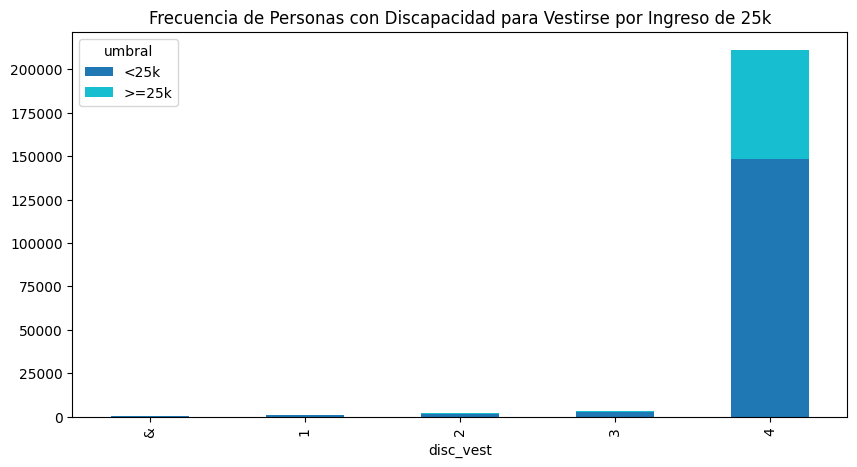

In [ ]:
# Graficar el ingreso de las personas según la discapacidad para vestirse
df_sub = pd.crosstab(index=df2['disc_vest'],
                    columns=df2['umbral'])
df_sub.plot(kind='bar',
                stacked=True,
                colormap='tab10', figsize=(10,5),
                title='Frecuencia de Personas con Discapacidad para Vestirse por Ingreso de 25k')

<Axes: title={'center': 'Frecuencia de Personas con Discapacidad para Hablar por Ingreso de 25k'}, xlabel='disc_habla'>

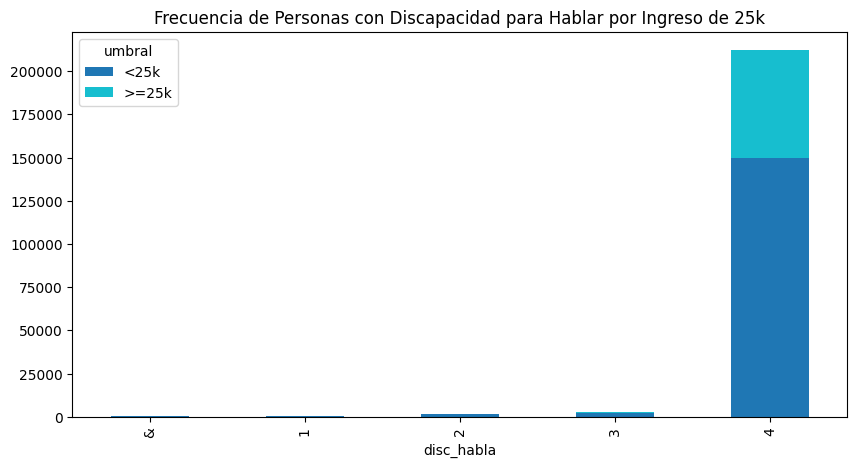

In [ ]:
# Graficar el ingreso de las personas según la discapacidad para hablar
df_sub = pd.crosstab(index=df2['disc_habla'],
                    columns=df2['umbral'])
df_sub.plot(kind='bar',
                stacked=True,
                colormap='tab10', figsize=(10,5),
                title='Frecuencia de Personas con Discapacidad para Hablar por Ingreso de 25k')

<Axes: title={'center': 'Frecuencia de Personas con Discapacidad para Realizar Actividades Diarias por Ingreso de 25k'}, xlabel='disc_acti'>

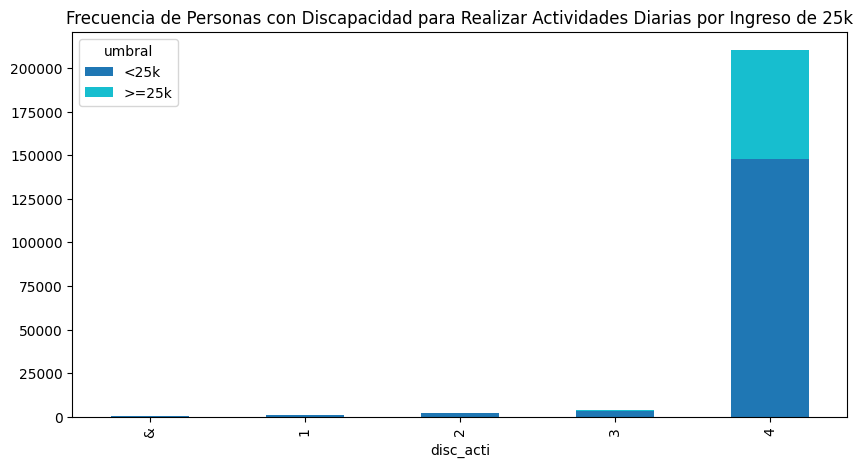

In [ ]:
# Graficar el ingreso de las personas según la discapacidad para realizar actividades diarias
df_sub = pd.crosstab(index=df2['disc_acti'],
                    columns=df2['umbral'])
df_sub.plot(kind='bar',
                stacked=True,
                colormap='tab10', figsize=(10,5),
                title='Frecuencia de Personas con Discapacidad para Realizar Actividades Diarias por Ingreso de 25k')

<Axes: title={'center': 'Motivos de No Trabajo Según Ingreso de 25k'}, xlabel='act_pnea1'>

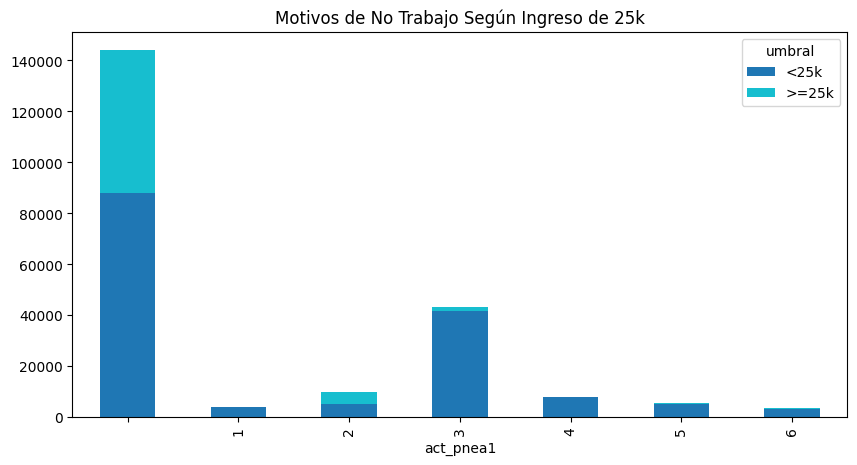

In [ ]:
df_sub = pd.crosstab(index=df2['act_pnea1'],
                    columns=df2['umbral'])
df_sub.plot(kind='bar',
                stacked=True,
                colormap='tab10', figsize=(10,5),
                title='Motivos de No Trabajo Según Ingreso de 25k')

<Axes: title={'center': 'Distribución de Horas Trabajadas de la Semana Pasada por Ingreso de 25k'}, xlabel='usotiempo1'>

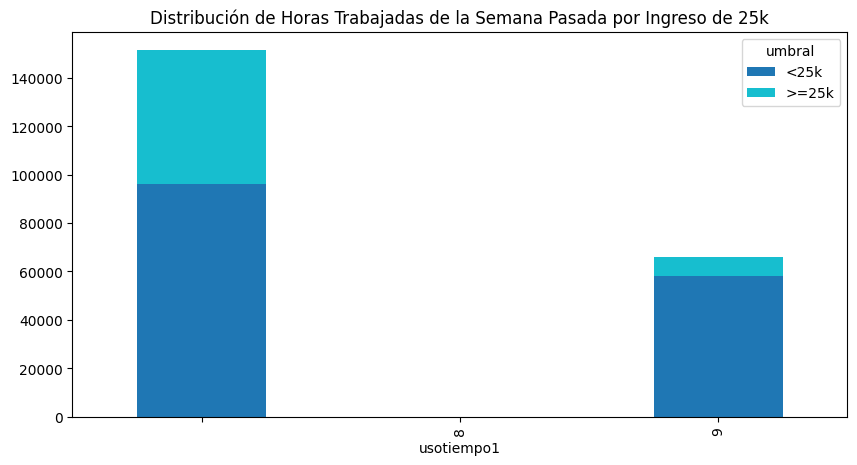

In [ ]:
df_sub = pd.crosstab(index=df2['usotiempo1'],
                    columns=df2['umbral'])
df_sub.plot(kind='bar',
                stacked=True,
                colormap='tab10', figsize=(10,5),
                title='Distribución de Horas Trabajadas de la Semana Pasada por Ingreso de 25k')

In [ ]:
df2["umbral"].dropna()

0          <25k
1         >=25k
3         >=25k
4          <25k
5         >=25k
          ...  
309676     <25k
309679    >=25k
309680     <25k
309681     <25k
309682     <25k
Name: umbral, Length: 217375, dtype: object

# Limpieza del código

### Columnas que queremos que se queden
1.   folioviv
1.   foliohog
1.   numren
1.   sexo
2.   edad
2.   dis_camin, dis_ver, dis_brazo, dis_apren, dis_oir, dis_vest, dis_habla, dis_acti
2.   nivelaprob
2.   edo_conyug
1.   hor_1
1.   usotiempo2
1.   usotiempo4
1.   usotiempo8
1.   atemed
2.   prob_sal
2.   pagoaten_2
2.   hijos_viv
2.   trabajo_mp
2.   motivo_aus
1.   act_pnea1
1.   num_traba
1.   entidad
1.   ing_tri_total
2.   ing_tri_max






In [ ]:
columnas_a_conservar = ['folioviv','foliohog','numren','sexo','edad','disc_camin','disc_ver','disc_brazo','disc_apren','disc_oir','disc_vest','disc_habla','disc_acti','nivelaprob','edo_conyug','hor_1','usotiempo2','usotiempo4','usotiempo8','atemed','prob_sal','pagoaten_2','hijos_viv','trabajo_mp','motivo_aus','act_pnea1','num_trabaj','entidad','ing_tri_total','ing_tri_max','etnia']
df_final = df2[columnas_a_conservar]
df_final = df_final[df_final['edad'] >= 18]
df_final.head()


,folioviv,foliohog,numren,sexo,edad,disc_camin,disc_ver,disc_brazo,disc_apren,disc_oir,...,pagoaten_2,hijos_viv,trabajo_mp,motivo_aus,act_pnea1,num_trabaj,entidad,ing_tri_total,ing_tri_max,etnia
0,100005002,1,1,2,91,3.0,4.0,4.0,4.0,4.0,...,,3,2,,5,,1,7434.78,7434.78,2
1,100005002,1,2,2,48,4.0,4.0,4.0,4.0,4.0,...,,1,1,,,1,1,35706.51,33749.99,2
3,100005003,1,1,1,68,4.0,4.0,4.0,4.0,4.0,...,2,,1,,,1,1,78016.28,52826.08,2
4,100005003,1,2,2,64,4.0,4.0,4.0,4.0,4.0,...,2,2,1,,,1,1,21032.60,11739.13,2
5,100005004,1,1,1,56,4.0,4.0,4.0,4.0,4.0,...,2,,1,,,1,1,53217.39,41478.26,2


In [ ]:
df_final['umbral'].value_counts

KeyError: 'umbral'

In [ ]:
df2['umbral'] = df2['umbral']

<ipython-input-247-5acf58e27e11>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['umbral'] = df2['umbral']


In [ ]:
#Eliminar los datos nulos de la columna ing_tri_total
df_final.drop(df_final[pd.isna(df_final['ing_tri_total'])].index, inplace=True)

In [ ]:
#Reemplazar todos los espacios vacíos por NaN
df_final = df_final.dropna()
df_final.shape

(180345, 31)

# Limpieza del dataset y análisis de columnas.

## Juntar discapacidades.
Revisar cada una de las columnas para ver si contiene algún tipo de discapacidad, en caso de al menos tener una discapacidad en la columna alguna_discapacidad agrega True.

Para el análisis de las columnas vamos a dropear los valores NaN del data frame df2_final

In [ ]:
# Remplazar los valores de & con 1
df_final[['disc_camin', 'disc_ver', 'disc_brazo', 'disc_apren', 'disc_oir', 'disc_vest', 'disc_habla', 'disc_acti']] = df_final[['disc_camin', 'disc_ver', 'disc_brazo', 'disc_apren', 'disc_oir', 'disc_vest', 'disc_habla', 'disc_acti']].replace("&","1")

In [ ]:
# Cambiar todos los datos que no sean 4 a False, True las demás.
df_final[['disc_camin', 'disc_ver', 'disc_brazo', 'disc_apren', 'disc_oir', 'disc_vest', 'disc_habla', 'disc_acti']] = df_final[['disc_camin', 'disc_ver', 'disc_brazo', 'disc_apren', 'disc_oir', 'disc_vest', 'disc_habla', 'disc_acti']].applymap(lambda x: False if x == '4' else True)

In [ ]:
# En la columna alguna_discapacidad se agrega True si en las otras columnas encuentra un True
df_final['alguna_discapacidad'] = df_final[['disc_camin', 'disc_ver', 'disc_brazo', 'disc_apren', 'disc_oir', 'disc_vest', 'disc_habla', 'disc_acti']].any(axis=1)
df_final = df_final.drop(columns=['disc_camin', 'disc_ver', 'disc_brazo', 'disc_apren', 'disc_oir', 'disc_vest', 'disc_habla', 'disc_acti'])
df_final.head()

,folioviv,foliohog,numren,sexo,edad,nivelaprob,edo_conyug,hor_1,usotiempo2,usotiempo4,...,hijos_viv,trabajo_mp,motivo_aus,act_pnea1,num_trabaj,entidad,ing_tri_total,ing_tri_max,etnia,alguna_discapacidad
0,100005002,1,1,2,91,2,5,,9,9,...,3,2,,5,,1,7434.78,7434.78,2,True
1,100005002,1,2,2,48,4,6,48,9,,...,1,1,,,1,1,35706.51,33749.99,2,True
3,100005003,1,1,1,68,4,2,40,9,9,...,,1,,,1,1,78016.28,52826.08,2,True
4,100005003,1,2,2,64,7,2,12,,9,...,2,1,,,1,1,21032.60,11739.13,2,True
5,100005004,1,1,1,56,7,2,68,9,9,...,,1,,,1,1,53217.39,41478.26,2,True


<Axes: title={'center': 'Frecuencia de Personas con Discapacidad por Ingreso de 25k (normalizado)'}, xlabel='alguna_discapacidad'>

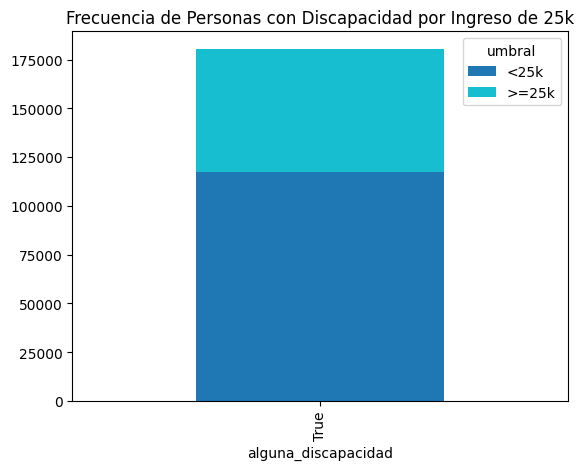

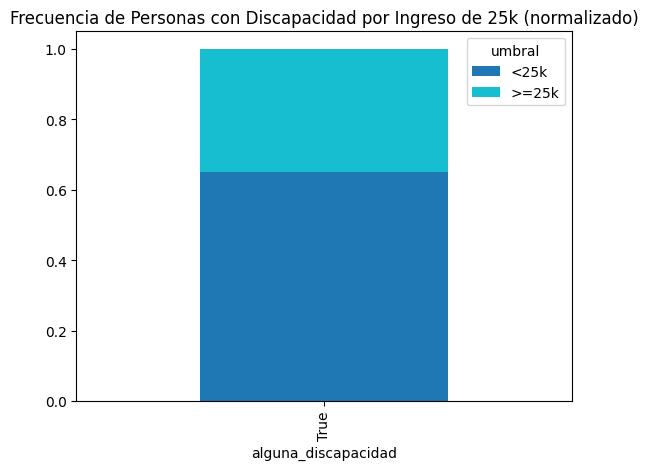

In [ ]:
df_subplot = pd.crosstab(index=df_final['alguna_discapacidad'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Personas con Discapacidad por Ingreso de 25k')
df_subplot = pd.crosstab(index=df_final['alguna_discapacidad'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Personas con Discapacidad por Ingreso de 25k (normalizado)')

<Axes: title={'center': 'Frecuencia de Personas con Discapacidad por Ingreso de 25k (normalizado)'}, xlabel='alguna_discapacidad'>

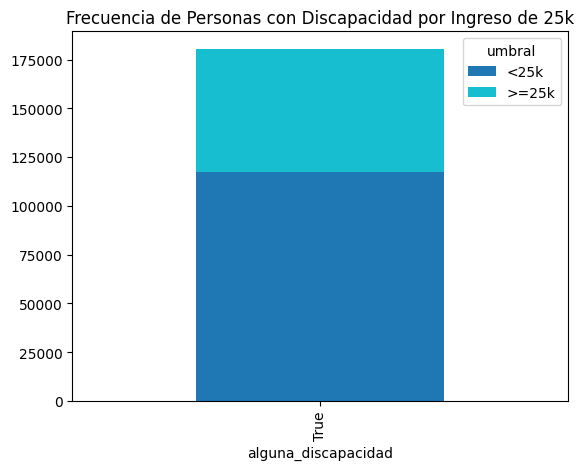

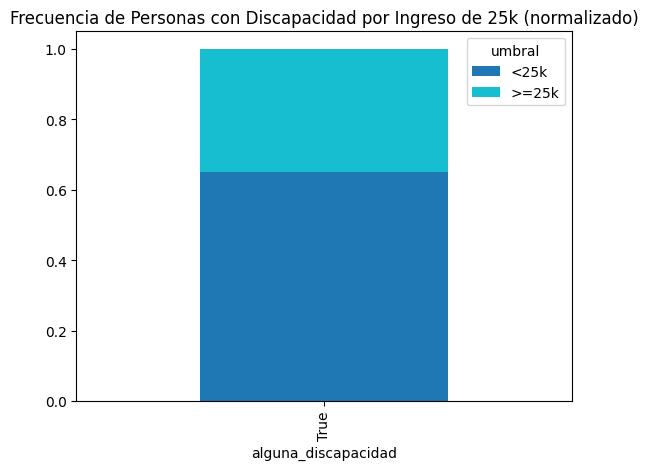

In [ ]:
df_subplot = pd.crosstab(index=df_final['alguna_discapacidad'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Personas con Discapacidad por Ingreso de 25k')
df_subplot = pd.crosstab(index=df_final['alguna_discapacidad'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Personas con Discapacidad por Ingreso de 25k (normalizado)')

# Correlación de las variables

<Axes: title={'center': 'Frecuencia de Sexo por Ingreso de 25k (normalizado)'}, xlabel='sexo'>

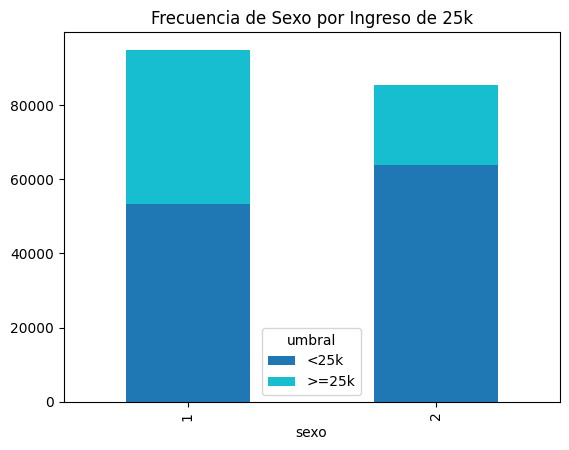

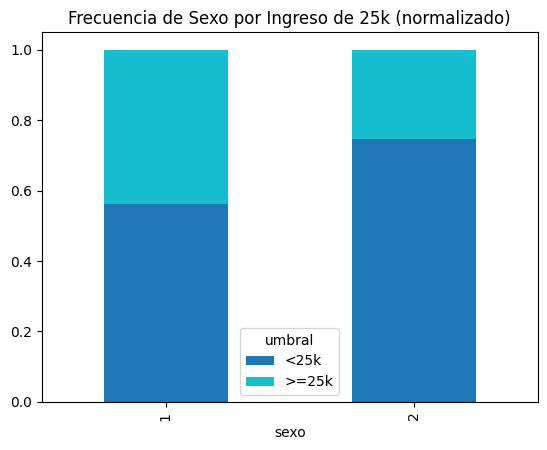

In [ ]:
#Sexo
df_subplot = pd.crosstab(index=df_final['sexo'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Sexo por Ingreso de 25k')
df_subplot = pd.crosstab(index=df_final['sexo'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Sexo por Ingreso de 25k (normalizado)')

<Axes: title={'center': 'Frecuencia de Edades por Ingreso de 25k (normalizado)'}, xlabel='edad'>

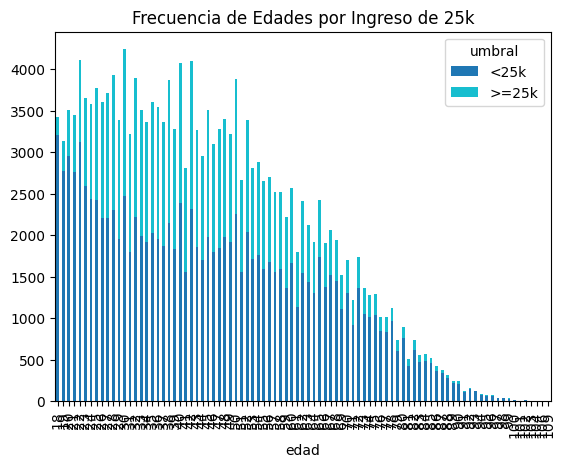

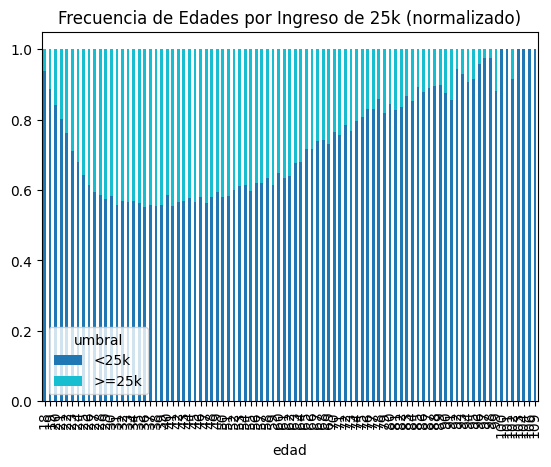

In [ ]:
#Edad
df_subplot = pd.crosstab(index=df_final['edad'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Edades por Ingreso de 25k')
df_subplot = pd.crosstab(index=df_final['edad'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Edades por Ingreso de 25k (normalizado)')

<Axes: title={'center': 'Frecuencia de Nivel de Estudio por Ingreso de 25k (normalizado)'}, xlabel='nivelaprob'>

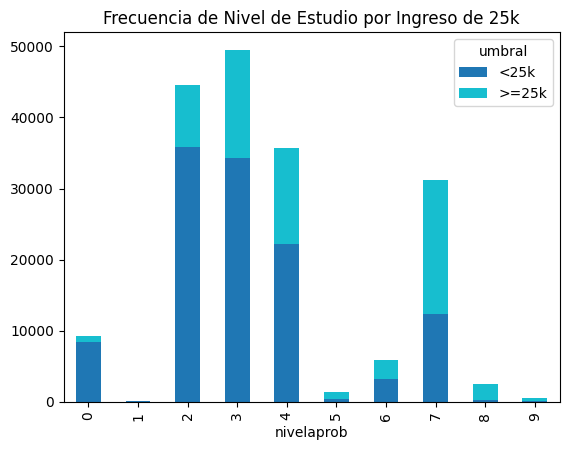

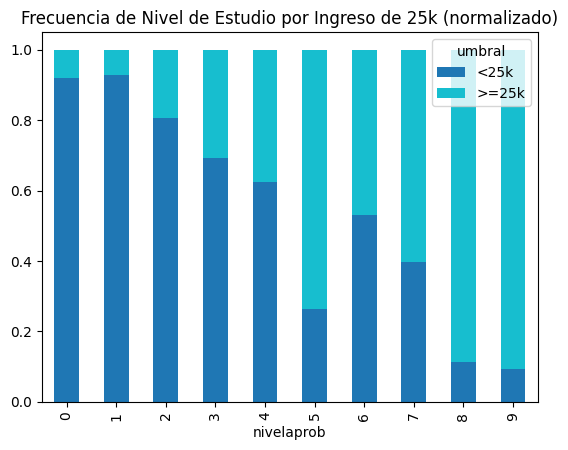

In [ ]:
# Nivel de estudios
df_subplot = pd.crosstab(index=df_final['nivelaprob'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Nivel de Estudio por Ingreso de 25k')
df_subplot = pd.crosstab(index=df_final['nivelaprob'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Nivel de Estudio por Ingreso de 25k (normalizado)')

<Axes: title={'center': 'Frecuencia de Estado Conyugal por Ingreso de 25k (normalizado)'}, xlabel='edo_conyug'>

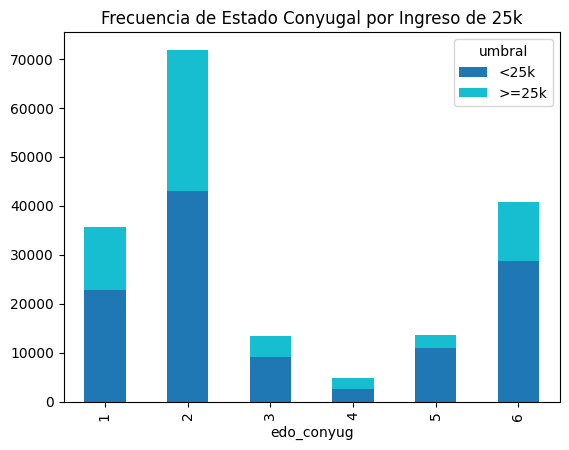

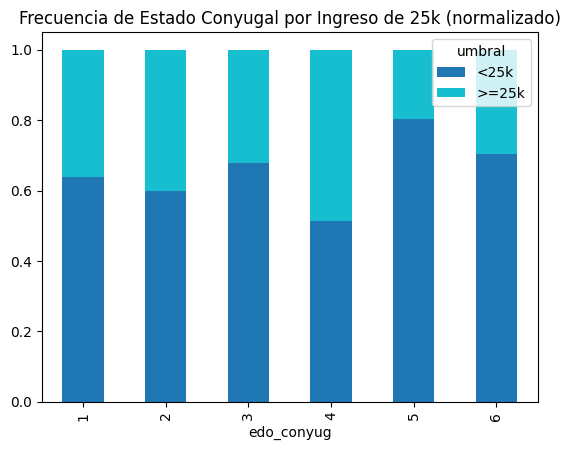

In [ ]:
# Estado conyugal
df_subplot = pd.crosstab(index=df_final['edo_conyug'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Estado Conyugal por Ingreso de 25k')
df_subplot = pd.crosstab(index=df_final['edo_conyug'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Estado Conyugal por Ingreso de 25k (normalizado)')

<Axes: title={'center': 'Frecuencia de Horas Trabajadas por Ingreso de 25k (normalizado)'}, xlabel='hor_1'>

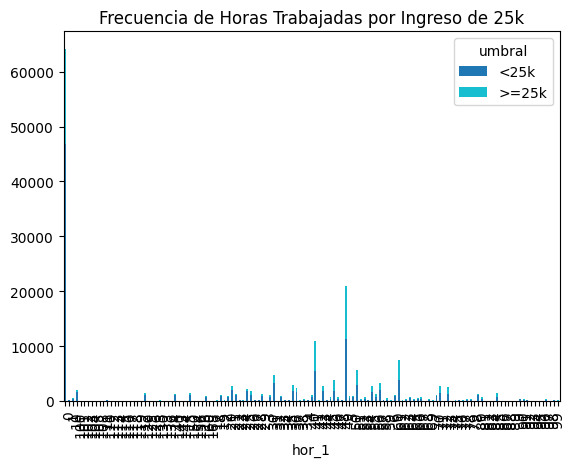

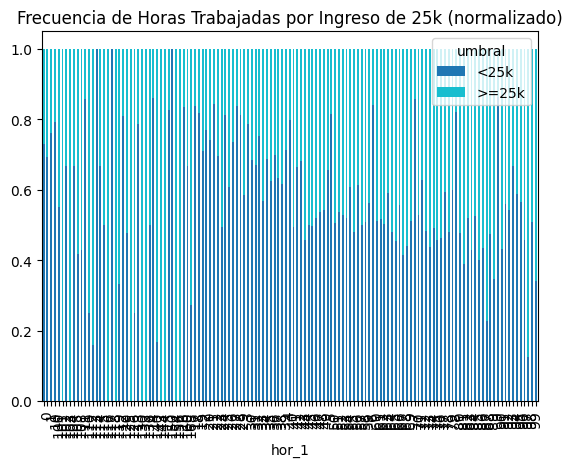

In [ ]:
# Horas trabajadas
df_subplot = pd.crosstab(index=df_final['hor_1'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Horas Trabajadas por Ingreso de 25k')
df_subplot = pd.crosstab(index=df_final['hor_1'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Horas Trabajadas por Ingreso de 25k (normalizado)')

<Axes: title={'center': 'Distribución de Horas Trabajadas de hace dos Semanas por Ingreso de 25k'}, xlabel='usotiempo2'>

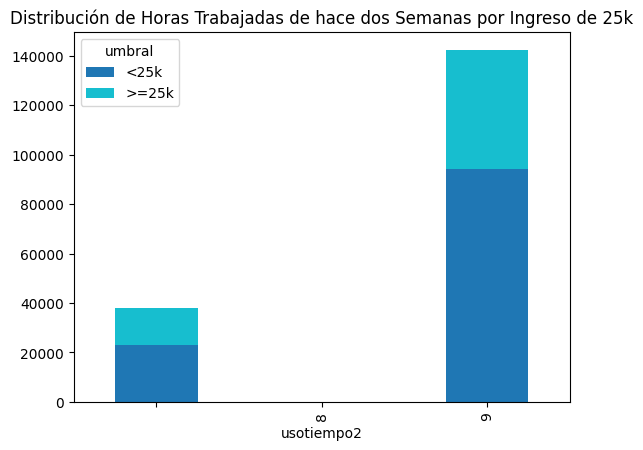

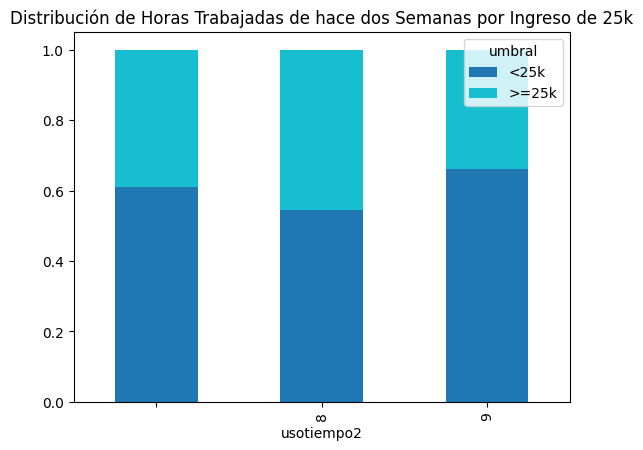

In [ ]:
# Uso tiempo 2
df_subplot = pd.crosstab(index=df_final['usotiempo2'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Distribución de Horas Trabajadas de hace dos Semanas por Ingreso de 25k')
df_subplot = pd.crosstab(index=df_final['usotiempo2'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Distribución de Horas Trabajadas de hace dos Semanas por Ingreso de 25k')

<Axes: title={'center': 'Datos normalizados'}, xlabel='usotiempo4'>

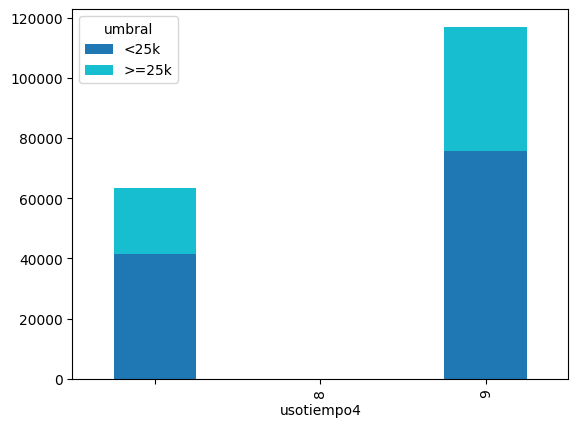

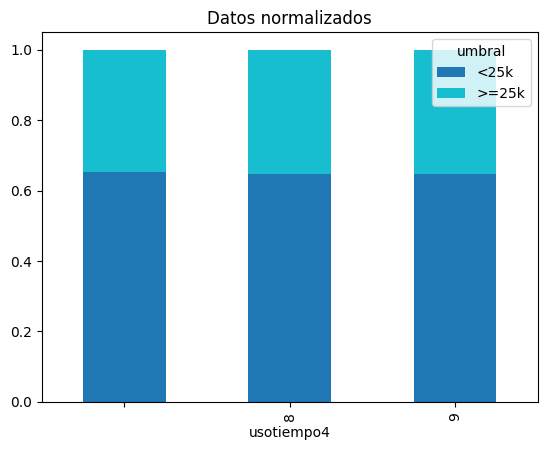

In [ ]:
# Nivel de estudios
df_subplot = pd.crosstab(index=df_final['usotiempo4'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10')
df_subplot = pd.crosstab(index=df_final['usotiempo4'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10', title= "Datos normalizados")

<Axes: title={'center': 'Datos normalizados'}, xlabel='usotiempo8'>

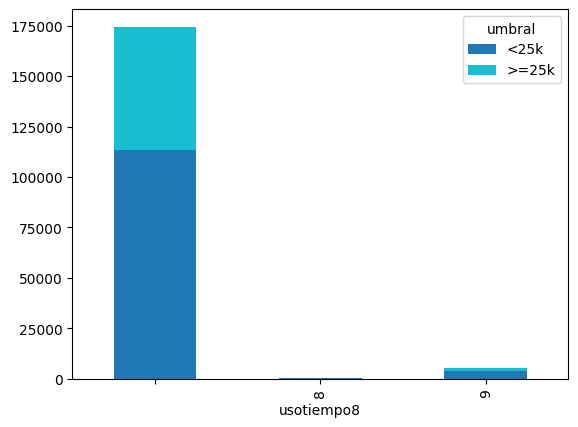

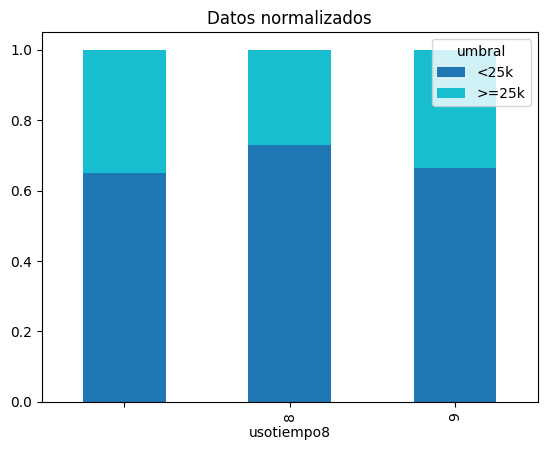

In [ ]:
# Uso tiempo 8
df_subplot = pd.crosstab(index=df_final['usotiempo8'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10')
df_subplot = pd.crosstab(index=df_final['usotiempo8'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10', title= "Datos normalizados")

<Axes: title={'center': 'Datos normalizados'}, xlabel='atemed'>

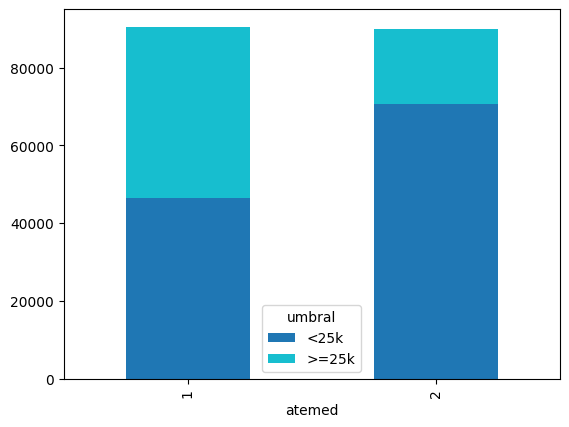

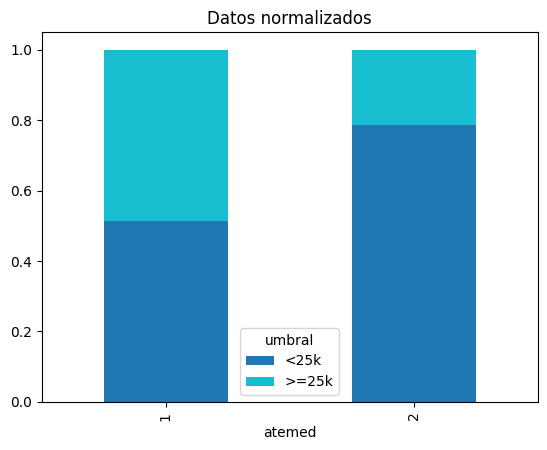

In [ ]:
# Atención médica

df_subplot = pd.crosstab(index=df_final['atemed'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10')
df_subplot = pd.crosstab(index=df_final['atemed'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10', title= "Datos normalizados")

<Axes: title={'center': 'Frecuencia de Personas con Problemas de Salud por Ingreso de 25k (normalizado)'}, xlabel='prob_sal'>

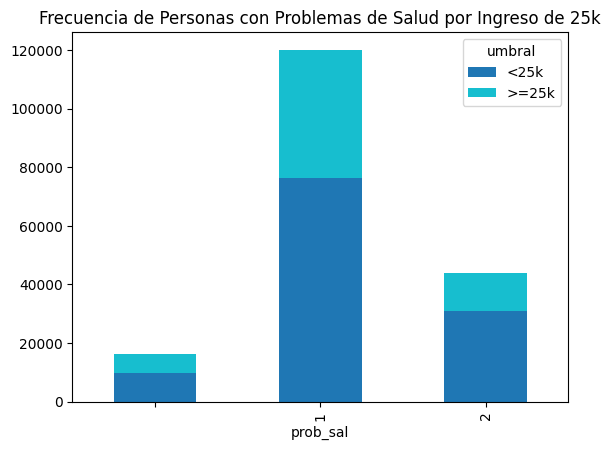

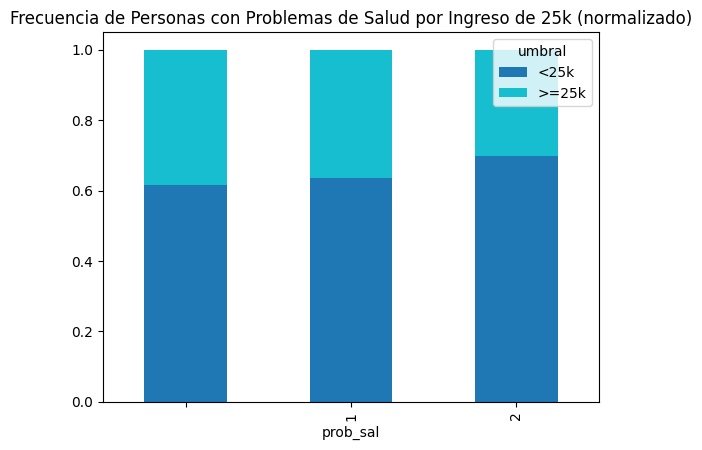

In [ ]:
# problemas de salud
df_subplot = pd.crosstab(index=df_final['prob_sal'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Personas con Problemas de Salud por Ingreso de 25k')
df_subplot = pd.crosstab(index=df_final['prob_sal'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Personas con Problemas de Salud por Ingreso de 25k (normalizado)')

<Axes: title={'center': 'Datos normalizados'}, xlabel='pagoaten_2'>

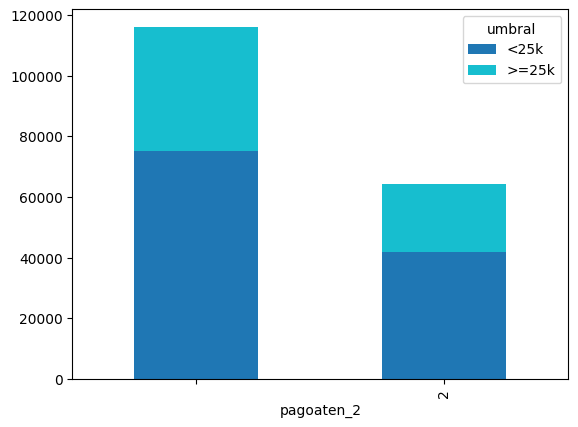

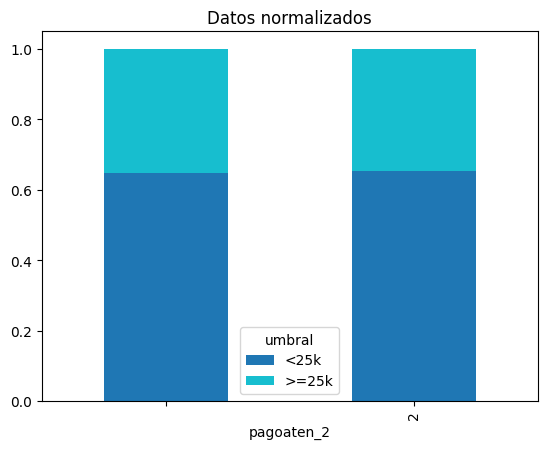

In [ ]:
# pago por medicamentos
df_subplot = pd.crosstab(index=df_final['pagoaten_2'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10')
df_subplot = pd.crosstab(index=df_final['pagoaten_2'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10', title= "Datos normalizados")

<Axes: title={'center': 'Frecuencia de Personas por Etnia -Ingreso de 25k'}, xlabel='etnia'>

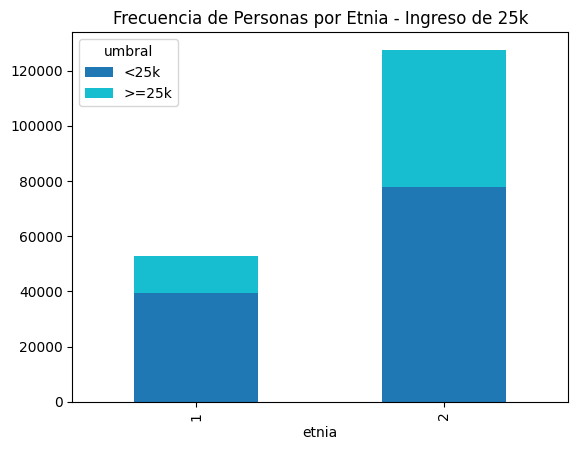

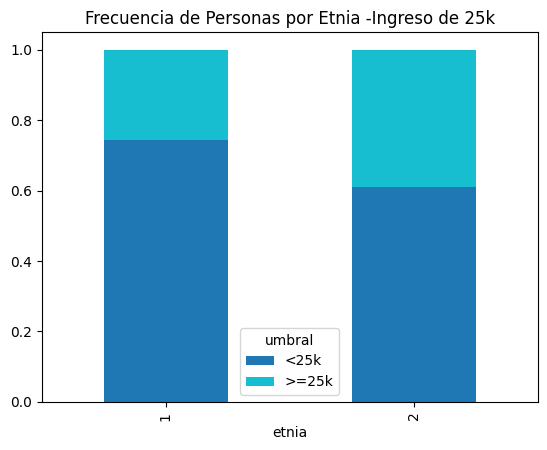

In [ ]:
# Etnia
df_subplot = pd.crosstab(index=df_final['etnia'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Personas por Etnia - Ingreso de 25k')
df_subplot = pd.crosstab(index=df_final['etnia'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Personas por Etnia -Ingreso de 25k')

<Axes: title={'center': 'Motivos de No Trabajo Según los Ingresos (Normalizado)'}, xlabel='act_pnea1'>

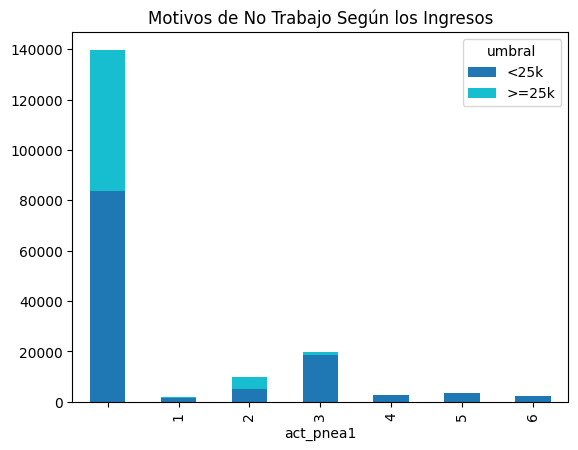

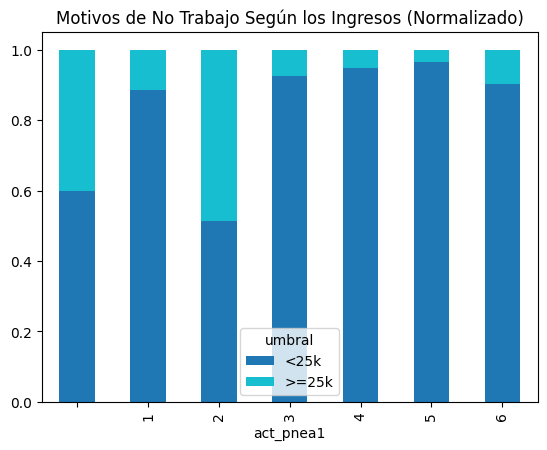

In [ ]:
# Primera actividad del integrante PNEA
df_subplot = pd.crosstab(index=df_final['act_pnea1'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Motivos de No Trabajo Según los Ingresos')
df_subplot = pd.crosstab(index=df_final['act_pnea1'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Motivos de No Trabajo Según los Ingresos (Normalizado)')

<Axes: title={'center': 'Frecuencia de Personas por Número de Trabajos - Ingreso de 25k (normalizado)'}, xlabel='num_trabaj'>

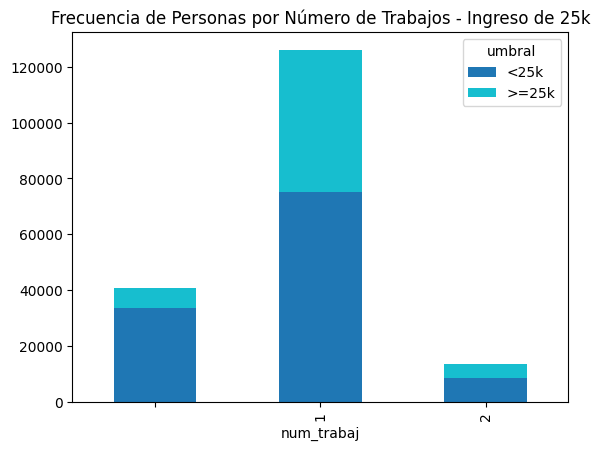

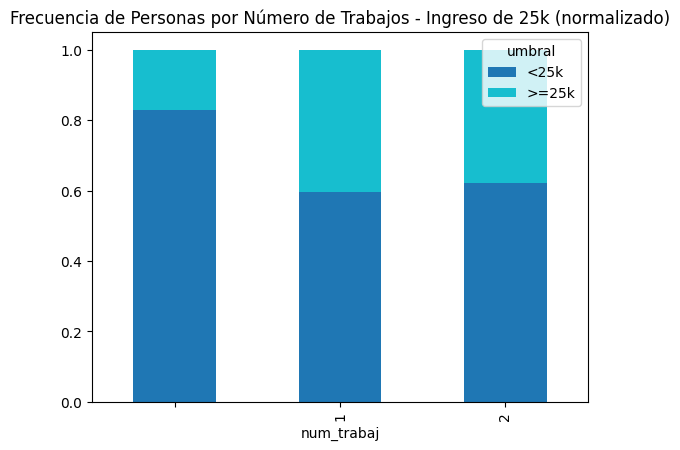

In [ ]:
# Número de trabajos
df_subplot = pd.crosstab(index=df_final['num_trabaj'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Personas por Número de Trabajos - Ingreso de 25k')
df_subplot = pd.crosstab(index=df_final['num_trabaj'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Personas por Número de Trabajos - Ingreso de 25k (normalizado)')

<Axes: title={'center': 'Frecuencia de Personas por Entidad - Ingreso de 25k (normalizado)'}, xlabel='entidad'>

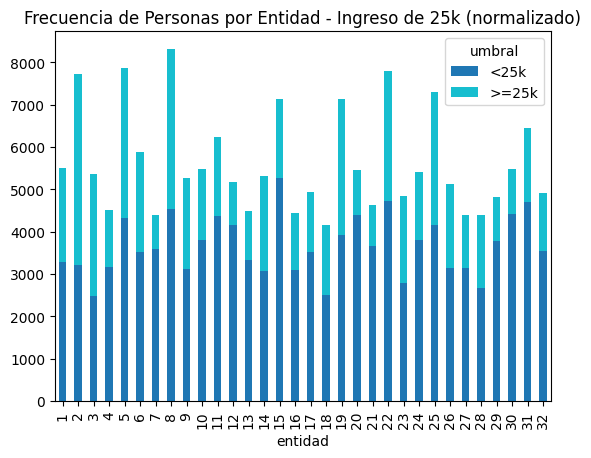

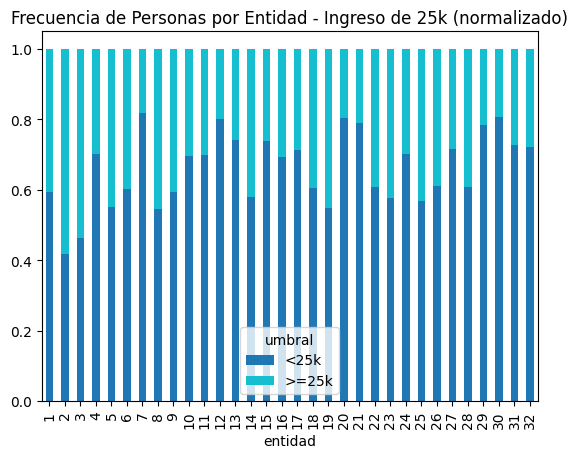

In [ ]:
# Entidad
df_subplot = pd.crosstab(index=df_final['entidad'],columns=df2['umbral'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Personas por Entidad - Ingreso de 25k (normalizado)')
df_subplot = pd.crosstab(index=df_final['entidad'],columns=df2['umbral'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Frecuencia de Personas por Entidad - Ingreso de 25k (normalizado)')

In [ ]:
df2.dtypes

Unnamed: 0         object
folioviv           object
foliohog           object
numren              int64
parentesco          int64
                   ...   
ing_tri_total     float64
ing_tri_max       float64
clave_max          object
umbral             object
rango_edad       category
Length: 194, dtype: object

In [ ]:
df_final.head()

,folioviv,foliohog,numren,sexo,edad,nivelaprob,edo_conyug,hor_1,usotiempo2,usotiempo4,...,hijos_viv,trabajo_mp,motivo_aus,act_pnea1,num_trabaj,entidad,ing_tri_total,ing_tri_max,etnia,alguna_discapacidad
0,100005002,1,1,2,91,2,5,,9,9,...,3,2,,5,,1,7434.78,7434.78,2,True
1,100005002,1,2,2,48,4,6,48,9,,...,1,1,,,1,1,35706.51,33749.99,2,True
3,100005003,1,1,1,68,4,2,40,9,9,...,,1,,,1,1,78016.28,52826.08,2,True
4,100005003,1,2,2,64,7,2,12,,9,...,2,1,,,1,1,21032.60,11739.13,2,True
5,100005004,1,1,1,56,7,2,68,9,9,...,,1,,,1,1,53217.39,41478.26,2,True


In [ ]:
for col in df_final.columns[3:-1]:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

corr = df_final.iloc[:, 3:-1].corr(method='kendall')
corr.style.background_gradient(cmap='coolwarm')

,sexo,edad,nivelaprob,edo_conyug,hor_1,usotiempo2,usotiempo4,usotiempo8,atemed,prob_sal,pagoaten_2,hijos_viv,trabajo_mp,motivo_aus,act_pnea1,num_trabaj,entidad,ing_tri_total,ing_tri_max,etnia
sexo,1.000000,0.026766,0.002091,0.078615,-0.197425,0.001638,-0.001480,0.030952,-0.017375,-0.066198,nan,0.020948,0.219486,-0.081941,0.109170,-0.005126,0.011424,-0.223431,-0.228433,-0.004970
edad,0.026766,1.000000,-0.300755,-0.079930,-0.059332,-0.000274,0.002914,-0.042277,-0.052009,-0.084369,nan,0.482485,0.266876,0.029387,-0.072747,0.047294,0.009700,-0.019488,-0.042375,-0.018341
nivelaprob,0.002091,-0.300755,1.000000,0.100060,0.022617,0.000112,0.002154,0.031121,-0.254310,-0.037580,nan,-0.427260,-0.151699,-0.162129,-0.167285,-0.067598,-0.017430,0.274493,0.282931,0.135450
edo_conyug,0.078615,-0.079930,0.100060,1.000000,-0.020679,0.002194,0.005065,-0.035407,-0.034165,-0.001527,nan,-0.214571,0.066218,-0.027609,0.108966,-0.041151,-0.010292,-0.051622,-0.051746,0.041917
hor_1,-0.197425,-0.059332,0.022617,-0.020679,1.000000,0.004595,0.002429,0.044307,-0.066476,0.004214,nan,-0.099855,-0.140226,-0.000184,-0.071080,0.028524,-0.021805,0.203649,0.211020,0.035172
usotiempo2,0.001638,-0.000274,0.000112,0.002194,0.004595,1.000000,0.506097,0.044438,0.001622,0.000110,nan,-0.002063,0.004567,nan,-0.003966,0.000291,-0.000657,-0.002734,-0.002111,0.004259
usotiempo4,-0.001480,0.002914,0.002154,0.005065,0.002429,0.506097,1.000000,0.234048,-0.002542,-0.004271,nan,-0.004292,0.005350,nan,-0.005884,0.001215,-0.005742,-0.000556,-0.000391,0.001665
usotiempo8,0.030952,-0.042277,0.031121,-0.035407,0.044307,0.044438,0.234048,1.000000,-0.001777,-0.029715,nan,-0.017330,-0.073872,-0.034893,0.032042,0.038125,0.020561,0.019463,0.013662,-0.026903
atemed,-0.017375,-0.052009,-0.254310,-0.034165,-0.066476,0.001622,-0.002542,-0.001777,1.000000,0.126315,nan,0.063591,-0.034138,0.121208,0.265188,0.101550,0.066557,-0.268060,-0.246922,-0.150608
prob_sal,-0.066198,-0.084369,-0.037580,-0.001527,0.004214,0.000110,-0.004271,-0.029715,0.126315,1.000000,nan,-0.029645,-0.061092,-0.081352,0.004902,0.020466,0.000460,-0.050998,-0.042482,-0.036843


<Axes: title={'center': 'Relación de la edad de las personas con los hijos vivos que tienen (normalizado)'}, xlabel='edad'>

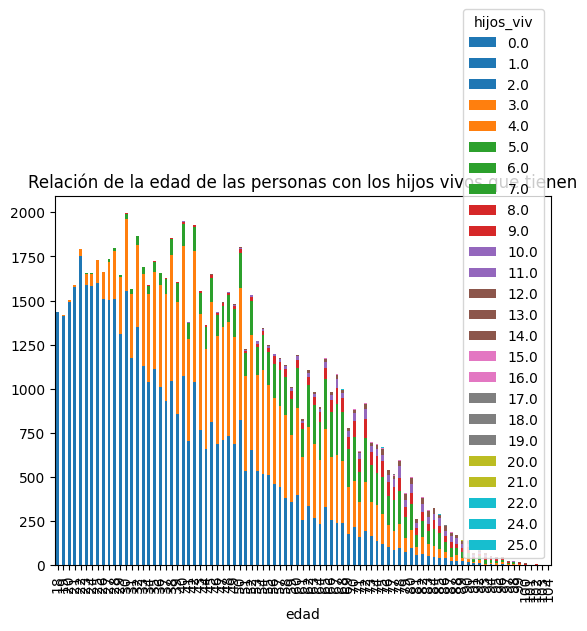

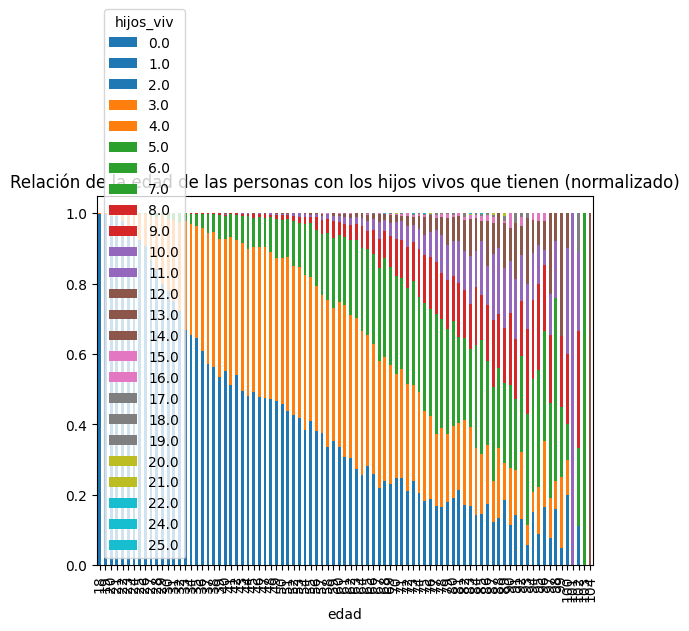

In [ ]:
df_subplot = pd.crosstab(index=df_final['edad'],columns=df_final['hijos_viv'])
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Relación de la edad de las personas con los hijos vivos que tienen')
df_subplot = pd.crosstab(index=df_final['edad'],columns=df_final['hijos_viv'],normalize='index')
df_subplot.plot(kind='bar', stacked=True, colormap='tab10',
                title='Relación de la edad de las personas con los hijos vivos que tienen (normalizado)')

La correlación entre la edad y el número de hijos puede indicar que a medida que las personas envejecen, es más probable que tengan más hijos. Esto se debe a que tienen más tiempo para formar una familia y es más probable que sus hijos vivan hasta la adultez.



### Limpieza dos

In [ ]:
df_final['usotiempo2'] = df_final['usotiempo2'].fillna(df_final['usotiempo2'].mean())

In [ ]:
df_final['usotiempo4'] = df_final['usotiempo4'].fillna(df_final['usotiempo4'].mean())

In [ ]:
df_final['hijos_viv'] = df_final['hijos_viv'].fillna(df_final['hijos_viv'].mean())

In [ ]:
df_final['motivo_aus'] = df_final['motivo_aus'].fillna(df_final['motivo_aus'].mean())

In [ ]:
df_final['act_pnea1'] = df_final['act_pnea1'].fillna(df_final['act_pnea1'].mean())

In [ ]:
df_final['num_trabaj'] = df_final['num_trabaj'].fillna(df_final['num_trabaj'].mean())

In [ ]:
df_final['hor_1'] = df_final['hor_1'].fillna(df_final['hor_1'].mean())

In [ ]:
df_final['usotiempo8'] = df_final['usotiempo8'].fillna(df_final['usotiempo8'].mean())

In [ ]:
df_final['prob_sal'] = df_final['prob_sal'].fillna(df_final['prob_sal'].mean())

In [ ]:
df_final = df_final.drop(columns=['trabajo_mp','pagoaten_2'])

In [ ]:
df_final.shape

(180345, 22)

In [ ]:
for col in df_final.columns[3:-1]:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

corr = df_final.iloc[:, 3:-1].corr(method='kendall')
corr.style.background_gradient(cmap='coolwarm')

,sexo,edad,nivelaprob,edo_conyug,hor_1,usotiempo2,usotiempo4,usotiempo8,atemed,prob_sal,hijos_viv,motivo_aus,act_pnea1,num_trabaj,entidad,ing_tri_total,ing_tri_max,etnia
sexo,1.000000,0.026766,0.002091,0.078615,-0.167264,0.072155,-0.050522,0.026019,-0.017375,-0.072875,-0.087988,-0.003217,-0.187579,0.152650,0.011424,-0.223431,-0.228433,-0.004970
edad,0.026766,1.000000,-0.300755,-0.079930,-0.061018,0.152087,0.101230,0.007621,-0.052009,-0.087938,0.297587,0.000230,-0.206383,0.210919,0.009700,-0.019488,-0.042375,-0.018341
nivelaprob,0.002091,-0.300755,1.000000,0.100060,0.026252,-0.170924,-0.039861,-0.017888,-0.254310,-0.028482,-0.282206,-0.012247,0.067140,-0.147058,-0.017430,0.274493,0.282931,0.135450
edo_conyug,0.078615,-0.079930,0.100060,1.000000,-0.018374,-0.111186,0.062434,-0.025699,-0.034165,0.002106,-0.119325,0.004157,0.045968,0.021481,-0.010292,-0.051622,-0.051746,0.041917
hor_1,-0.167264,-0.061018,0.026252,-0.018374,1.000000,0.070283,0.062702,0.034599,-0.067951,0.008230,-0.020056,0.007225,0.049795,-0.052630,-0.023220,0.172883,0.178621,0.032165
usotiempo2,0.072155,0.152087,-0.170924,-0.111186,0.070283,1.000000,0.407241,0.049087,0.093468,-0.008651,0.102203,-0.002247,-0.138007,0.030521,-0.006412,-0.031084,-0.044562,-0.042176
usotiempo4,-0.050522,0.101230,-0.039861,0.062434,0.062702,0.407241,1.000000,0.022359,-0.006113,-0.005390,0.020522,0.002354,-0.004133,0.001963,-0.012876,0.016992,0.008200,0.014619
usotiempo8,0.026019,0.007621,-0.017888,-0.025699,0.034599,0.049087,0.022359,1.000000,0.014246,-0.002312,0.012789,-0.001677,0.017756,-0.002338,0.004813,-0.004170,-0.007133,0.002905
atemed,-0.017375,-0.052009,-0.254310,-0.034165,-0.067951,0.093468,-0.006113,0.014246,1.000000,0.111828,0.042512,0.024982,0.059767,0.038566,0.066557,-0.268060,-0.246922,-0.150608
prob_sal,-0.072875,-0.087938,-0.028482,0.002106,0.008230,-0.008651,-0.005390,-0.002312,0.111828,1.000000,-0.017023,0.020749,0.031087,-0.038565,-0.003700,-0.038209,-0.028327,-0.025920


In [ ]:
df_final.head()


,folioviv,foliohog,numren,sexo,edad,nivelaprob,edo_conyug,hor_1,usotiempo2,usotiempo4,...,prob_sal,hijos_viv,motivo_aus,act_pnea1,num_trabaj,entidad,ing_tri_total,ing_tri_max,etnia,alguna_discapacidad
0,100005002,1,1,2,91,2,5,42.472824,9.000000,9.000000,...,1.0,3.000000,6.517808,5.000000,1.097787,1,7434.78,7434.78,2,True
1,100005002,1,2,2,48,4,6,48.000000,9.000000,8.999129,...,1.0,1.000000,6.517808,3.093762,1.000000,1,35706.51,33749.99,2,True
3,100005003,1,1,1,68,4,2,40.000000,9.000000,9.000000,...,1.0,2.656321,6.517808,3.093762,1.000000,1,78016.28,52826.08,2,True
4,100005003,1,2,2,64,7,2,12.000000,8.999537,9.000000,...,1.0,2.000000,6.517808,3.093762,1.000000,1,21032.60,11739.13,2,True
5,100005004,1,1,1,56,7,2,68.000000,9.000000,9.000000,...,1.0,2.656321,6.517808,3.093762,1.000000,1,53217.39,41478.26,2,True


In [ ]:
df_final.shape

(180345, 22)

In [ ]:
X = df_final.drop(['umbral'], axis=1)

y = df_final['umbral']

X.head()

KeyError: "['umbral'] not found in axis"

In [ ]:
X=X.applymap(lambda x: np.nan if x=='?' else x)
X.head()

In [ ]:
from sklearn.feature_selection import VarianceThreshold
p=0.5
sel = VarianceThreshold(threshold=(p * (1 - p)))
X_new=sel.fit_transform(X)
print(X.shape)
print(X_new.shape)

def get_matching_column(df, numpy):
    columns_names=[]
    for i in range(X_new.shape[1]):
      numpy_column=X_new[:,i]
      for column_name in df.columns:
          if (df[column_name] == numpy_column).all():
            columns_names.append(column_name)
    return columns_names

column_names = get_matching_column(X, X_new)
print(X.columns)
print("Column Names", column_names)

In [ ]:
df_final.isna().sum()

df_final['umbral']

### Selección de Características univariadas

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

def get_matching_column(df, numpy):
    columns_names=[]
    for i in range(X_new.shape[1]):
      numpy_column=X_new[:,i]
      for column_name in df.columns:
          if (df[column_name] == numpy_column).all():
            columns_names.append(column_name)
    return columns_names


X_new = SelectKBest(f_classif, k=8).fit_transform(X, y)
print(X.shape)
print(X_new.shape)
#print(X_new)

column_names = get_matching_column(X, X_new)
print("Column Names", column_names)

### Selección de características usando SelectFromModel

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel

lsvc = LinearSVC(C=1000.0, penalty="l1", dual=False).fit(X, y)
model = SelectFromModel(lsvc, prefit=True)
X_new = model.transform(X)

print(X.shape)
print(X_new.shape)

column_names = get_matching_column(X, X_new)
print("Column Names", column_names)